# Build and train MicNet

In [20]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage

import time
import torch
import torch.hub
import torch.nn
import tifffile

from MicNet_model import *
from utils_data import Dataset
from utils_data import normalize, augmentor
from utils_eval import NCESoftmaxLoss, NCECriterion

## 1) Load data

(7386, 7388)


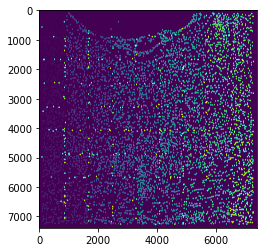

In [21]:
count_stat = pd.read_csv("./output/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_count_stat.csv", index_col=0)
count = pd.read_csv("./Sample_data/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26.csv", index_col=0)
count = count.loc[:, count_stat.columns.values]

image_file = "./output/Dataset_MERFISH//mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_pseuso_image_v2.pt"
image = torch.load(image_file)
print(image.shape)
image_norm = image.copy()
plt.imshow(image_norm)
plt.show()

In [26]:
transformation_file = "./Sample_data/Dataset_MERFISH/mouse_hypothalamus_MERFISH_Animal_18_Bregma_0.26_v2.csv"
pd_meta = pd.read_table(transformation_file, index_col=0, sep=",")
pd_meta.loc[:, 'Centroid_X'] *= 4
pd_meta.loc[:, 'Centroid_Y'] *= 4
print(pd_meta.shape)
print(count.shape)

(5555, 170)
(5555, 161)


In [27]:
pd_meta

,Cell_ID,Animal_ID,Animal_sex,Behavior,Bregma,Centroid_X,Centroid_Y,Cell_class,Neuron_cluster_ID,Ace2,...,Penk,Scg2,Sln,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf
2,e9d73818-5233-41aa-b387-25257543d9de,18,Female,Parenting,0.26,132.412808,588.180461,Inhibitory,I-17,0.000000,...,0.000000,0.000000,0.785172,0.000000,0.252832,0.000000,0.000000,0.000000,0.000000,0.301008
3,704470b6-2455-4e8d-be4c-6337b017efd0,18,Female,Parenting,0.26,137.852216,244.618301,Inhibitory,I-17,0.000000,...,0.053157,0.000000,0.954474,0.022710,0.551244,0.000000,0.000000,0.000000,0.029035,0.054919
4,16b60d1b-e1b9-40e3-bd99-848f2c03047a,18,Female,Parenting,0.26,149.792984,315.350523,Inhibitory,I-17,0.000000,...,0.043167,0.000000,1.025583,0.013712,0.781845,0.000000,0.000000,0.000000,0.029430,0.000000
5,f5346407-1501-407d-b981-445f46023b16,18,Female,Parenting,0.26,154.099004,369.059756,Inhibitory,I-17,0.000000,...,0.000000,0.000000,0.685039,0.000000,0.114975,0.000000,0.000000,0.000000,0.029108,0.000000
6,b1ab923f-d5fd-4eff-99d3-76bb333db9b2,18,Female,Parenting,0.26,162.245088,434.140557,Inhibitory,I-17,0.000000,...,3.289237,0.000000,0.662800,0.015281,0.000000,0.000000,0.000000,0.000000,0.027072,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5552,331a482f-2b97-46d0-999f-bddc91395d51,18,Female,Parenting,0.26,7158.664492,5665.132542,OD Mature 1,NaN,0.000000,...,0.013043,0.000000,0.000000,0.015949,0.000000,0.004345,0.019068,0.020962,0.007964,0.000000
5553,1dc07ac5-7713-4851-81e7-82190dd4ad81,18,Female,Parenting,0.26,7217.570824,5680.852131,OD Mature 1,NaN,0.000000,...,0.010604,0.012548,0.000000,0.019167,0.005378,0.000000,0.000000,0.031773,0.007725,0.000000
5554,b548b5c3-4286-4426-b95a-2afe715420f7,18,Female,Parenting,0.26,6735.179840,6463.448364,Inhibitory,I-1,0.825408,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031846
5555,2d19a0f3-2196-41ab-8ed7-486fca9db40b,18,Female,Parenting,0.26,6906.159372,6479.665867,Inhibitory,I-1,0.000000,...,0.000000,0.000000,0.215245,0.000000,0.051812,0.065958,0.074774,0.000000,0.001262,0.097569


In [66]:
# Split training and testing
np.random.seed(100)
indexes_all = pd_meta.index.values
training_indexes = np.random.choice(indexes_all, int(len(indexes_all) * 0.97), replace=False)
testing_indexes = [_ for _ in indexes_all if _ not in training_indexes]
print("#Training: {}, #Testing: {}".format(len(training_indexes), len(testing_indexes)))
training_indexes.sort()
testing_indexes.sort()

#Training: 5388, #Testing: 167


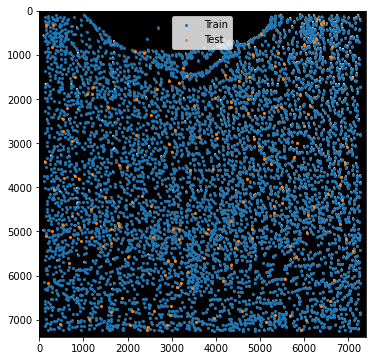

In [67]:
# Plot training & testing distribution
plt.figure(figsize=(6, 6))
plt.imshow(image_norm, cmap="gray")
coords_x = pd_meta.loc[training_indexes, "Centroid_X"].values
coords_y = pd_meta.loc[training_indexes, "Centroid_Y"].values
plt.scatter(coords_x, coords_y, s=4, label="Train")
coords_x = pd_meta.loc[testing_indexes, "Centroid_X"].values
coords_y = pd_meta.loc[testing_indexes, "Centroid_Y"].values
plt.scatter(coords_x, coords_y, s=4, label="Test")
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.legend()
plt.show()

In [68]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max
count_max = np.log2(count_stat.loc['max', :].values + 1)
count_max[count_max < 1] = 1
count = count/count_max

In [69]:
count

,Ace2,Adora2a,Aldh1l1,Amigo2,Ano3,Aqp4,Ar,Arhgap36,Avpr1a,Avpr2,...,Penk,Scg2,Sln,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf
2,0.000000,0.000000,0.046903,0.000000,0.152089,0.000000,0.107352,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.208355,0.000000,0.252172,0.000000,0.000000,0.000000,0.000000,0.056709
3,0.000000,0.078249,0.000000,0.000000,0.099314,0.000000,0.067074,0.055102,0.000000,0.000000,...,0.008018,0.000000,0.235652,0.003019,0.448030,0.000000,0.000000,0.000000,0.022467,0.012079
4,0.000000,0.000000,0.000000,0.131935,0.140810,0.000000,0.105362,0.000000,0.000000,0.000000,...,0.006555,0.000000,0.246111,0.001834,0.558919,0.000000,0.000000,0.000000,0.022765,0.000000
5,0.000000,0.038064,0.000000,0.104469,0.165056,0.000000,0.112952,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.190347,0.000000,0.128846,0.000000,0.000000,0.000000,0.022523,0.000000
6,0.000000,0.134258,0.028252,0.000000,0.144583,0.047644,0.000000,0.072931,0.101787,0.000000,...,0.179849,0.000000,0.186131,0.002041,0.000000,0.000000,0.000000,0.000000,0.020987,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5552,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035685,0.000000,0.000000,...,0.002021,0.000000,0.000000,0.002130,0.000000,0.000742,0.001552,0.008199,0.006284,0.000000
5553,0.000000,0.000000,0.000000,0.000000,0.000000,0.029744,0.000000,0.000000,0.000000,0.000000,...,0.001646,0.006581,0.000000,0.002554,0.006709,0.000000,0.000000,0.012321,0.006097,0.000000
5554,0.049769,0.000000,0.000000,0.061601,0.042564,0.000000,0.129285,0.051118,0.000000,0.101445,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007120
5555,0.000000,0.000000,0.027704,0.047180,0.000000,0.025198,0.087309,0.039063,0.099921,0.000000,...,0.000000,0.000000,0.077769,0.000000,0.061651,0.010794,0.005879,0.000000,0.001002,0.020841


In [70]:
PATCH_SIZE = 512

In [71]:
hue_order = list(set(pd_meta['Cell_class'].values))
hue_order.sort()
hue_order = np.array(hue_order)
print(hue_order)

['Ambiguous' 'Astrocyte' 'Endothelial 1' 'Endothelial 2' 'Endothelial 3'
 'Ependymal' 'Excitatory' 'Inhibitory' 'Microglia' 'OD Immature 1'
 'OD Immature 2' 'OD Mature 1' 'OD Mature 2' 'OD Mature 3' 'OD Mature 4'
 'Pericytes']


In [34]:
# Create pc components
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pc_components = pca.fit_transform(count)
print(pc_components.shape)

for i in range(3):
    pd_meta.loc[:, 'pc{}'.format(i + 1)] = pc_components[:, i]
pd_meta

(5555, 3)


,Cell_ID,Animal_ID,Animal_sex,Behavior,Bregma,Centroid_X,Centroid_Y,Cell_class,Neuron_cluster_ID,Ace2,...,Sst,Tac1,Tac2,Th,Trh,Ucn3,Vgf,pc1,pc2,pc3
2,e9d73818-5233-41aa-b387-25257543d9de,18,Female,Parenting,0.26,132.412808,588.180461,Inhibitory,I-17,0.000000,...,0.000000,0.252832,0.000000,0.000000,0.000000,0.000000,0.301008,-1.145454,0.211174,0.029827
3,704470b6-2455-4e8d-be4c-6337b017efd0,18,Female,Parenting,0.26,137.852216,244.618301,Inhibitory,I-17,0.000000,...,0.022710,0.551244,0.000000,0.000000,0.000000,0.029035,0.054919,-0.988073,0.430404,-0.210395
4,16b60d1b-e1b9-40e3-bd99-848f2c03047a,18,Female,Parenting,0.26,149.792984,315.350523,Inhibitory,I-17,0.000000,...,0.013712,0.781845,0.000000,0.000000,0.000000,0.029430,0.000000,-0.817129,0.045867,-0.240124
5,f5346407-1501-407d-b981-445f46023b16,18,Female,Parenting,0.26,154.099004,369.059756,Inhibitory,I-17,0.000000,...,0.000000,0.114975,0.000000,0.000000,0.000000,0.029108,0.000000,-1.021269,0.237370,0.040909
6,b1ab923f-d5fd-4eff-99d3-76bb333db9b2,18,Female,Parenting,0.26,162.245088,434.140557,Inhibitory,I-17,0.000000,...,0.015281,0.000000,0.000000,0.000000,0.000000,0.027072,0.000000,-0.779689,0.024292,-0.064119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5552,331a482f-2b97-46d0-999f-bddc91395d51,18,Female,Parenting,0.26,7158.664492,5665.132542,OD Mature 1,NaN,0.000000,...,0.015949,0.000000,0.004345,0.019068,0.020962,0.007964,0.000000,1.134897,0.372198,-0.184741
5553,1dc07ac5-7713-4851-81e7-82190dd4ad81,18,Female,Parenting,0.26,7217.570824,5680.852131,OD Mature 1,NaN,0.000000,...,0.019167,0.005378,0.000000,0.000000,0.031773,0.007725,0.000000,1.169202,0.340532,-0.018145
5554,b548b5c3-4286-4426-b95a-2afe715420f7,18,Female,Parenting,0.26,6735.179840,6463.448364,Inhibitory,I-1,0.825408,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031846,-0.420119,-0.086043,-0.403057
5555,2d19a0f3-2196-41ab-8ed7-486fca9db40b,18,Female,Parenting,0.26,6906.159372,6479.665867,Inhibitory,I-1,0.000000,...,0.000000,0.051812,0.065958,0.074774,0.000000,0.001262,0.097569,-0.879573,0.146747,-0.091096


In [35]:
# Create pseudo_image

n_genes_for_image = 3
gene_names_for_image = count_stat.columns.values[np.argsort(count_stat.loc['std', :].values)[::-1][:3]]

from tqdm import tqdm
pseudo_image = np.zeros((image_norm.shape[0], image_norm.shape[1], n_genes_for_image + 1))
cell_ids = pd_meta.index.values
for cell_id in tqdm(cell_ids):
    # 0st channel: Cell category; 0 is background
    pseudo_image[image_norm == cell_id, 0] = np.argmax(hue_order == pd_meta.loc[cell_id, "Cell_class"]) + 1
    
    '''
    # rest channels: Gene expression
    pseudo_image[image_norm == cell_id, 1:] = count.loc[cell_id, gene_names_for_image].values
    '''
    
    # rest channels: PC components
    pseudo_image[image_norm == cell_id, 1:] = pd_meta.loc[cell_id, ['pc1', 'pc2', 'pc3']]


100%|██████████| 5555/5555 [27:47<00:00,  3.33it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


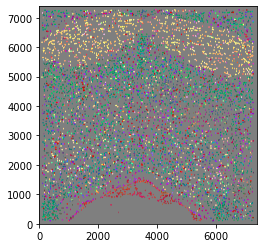

In [36]:
plt.imshow(pseudo_image[:, :, 1:4]/2 + 0.5)
plt.ylim(0, pseudo_image.shape[0])
plt.show()

In [37]:

torch.save(pseudo_image, "./output/Dataset_MERFISH/2_pseudo_image_pc_v2.pt")

In [38]:
n_genes_for_image = 3
pseudo_image = torch.load("./output/Dataset_MERFISH/2_pseudo_image_pc_v2.pt")

## 2) Check data loader

In [39]:
# from utils_data import Dataset
# from utils_data import normalize, augmentor

import numpy as np
import math
import skimage
import skimage.transform

import torch
import torch.utils
import torch.utils.data

def normalize(image):
    return image
    
def augmentor(image, label=None):
    """Do image shape and color augmentation.
    
    Args:
        image: [h, w, c], float
    """
    n_channels = image.shape[2]
    
    # Shape augmentation
    if np.random.uniform(0, 1) < 0.8:
        # Projective transform
        scale = np.random.uniform(0.9, 1.1)
        aspect_ratio = np.random.uniform(0.9, 1.1)
        rotation = np.random.uniform(-0.1, 0.1)
        translationX = np.random.uniform(-10, 10)
        translationY = np.random.uniform(-10, 10)
        g = np.random.uniform(-0.001, 0.001)
        h = np.random.uniform(-0.001, 0.001)

        matrix = np.array([[math.cos(rotation) * scale * aspect_ratio, -math.sin(rotation), translationX],
                          [math.sin(rotation), math.cos(rotation) * scale / aspect_ratio, translationY],
                          [g, h, 1]])
        tform = skimage.transform.ProjectiveTransform(matrix=matrix)
        image_aug = np.zeros_like(image, dtype=np.float)
        for ch in range(n_channels):
            image_aug[..., ch] = skimage.transform.warp(image[..., ch], tform, preserve_range=True)
        
        image = image_aug
        
        if label is not None:
            label_aug = np.zeros_like(label, dtype=np.int)
            label_aug = skimage.transform.warp(label, tform, preserve_range=True, order=0)
            label = label_aug
    if np.random.uniform(0, 1) < 0.5:
        # Do 50% vertical flipping
        image = image[::-1, :, :]
        
        if label is not None:
            label = label[::-1, :]
    if np.random.uniform(0, 1) < 0.5:
        # Do 50% horizontal flipping
        image = image[:, ::-1, :]
        
        if label is not None:
            label = label[:, ::-1]
            
    '''
    # Color augmentation
    # 1) add a global shifting for all channels
    image = image + np.random.randn(1)[0] * 0.1

    # 2) add a shifting & variance for each channel
    for ch in range(n_channels):
        image[:, :, ch] = image[:, :, ch] * np.clip(np.random.randn(1)[0] * 0.2 + 1, 0.8, 1.2) + np.random.randn(1)[0] * 0.3
    '''
        
    if label is not None:
        return image, label
    else:
        return image
    
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: center of image; x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    row_end = row_start + patch_size
    col_end = col_start + patch_size
    _image = image[max(row_start, 0):row_end, max(col_start, 0):col_end, ...]
    if len(image.shape) == 2:
        image_temp = np.zeros((patch_size, patch_size))
    else:
        image_temp = np.zeros((patch_size, patch_size, image.shape[2]))
    
    if _image.shape[0] == 0 or _image.shape[1] == 0:
        print(coords, "0 shape detected")
        return image_temp
    if _image.shape[0] == patch_size and _image.shape[1] == patch_size:
        return _image
    if row_start < 0:
        _row_start = -row_start
    else:
        _row_start = 0
    if col_start < 0:
        _col_start = -col_start
    else:
        _col_start = 0
    image_temp[_row_start:_row_start + _image.shape[0], _col_start:_col_start + _image.shape[1], ...] = _image
    return image_temp
            
    
    # return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

class Dataset(torch.utils.data.Dataset):
    __initialized = False
    def __init__(self, indexes, image, count_df, meta_df, augmentation=False):
        """
        Args:
            indexes: index used for both count_df and meta_df
        """
        self.indexes = indexes
        self.image = image
        self.count_df = count_df
        self.meta_df = meta_df
        self.augmentation = augmentation
        self.__initialized = True

    def __len__(self):
        """Denotes the number of samples"""
        return len(self.indexes)
    
    def __getitem__(self, index):
        """Generate one batch of data.
        
        Returns:
            index: indexes of samples (long)
        """
        # Generate data
        data = self.__data_generation(self.indexes[index])

        return data, index
    
    def __data_generation(self, indexes):
        """Generates data containing batch_size samples.
        
        Returns:
            data: a dictionary with data.image in [b, ch, h, w]; data.gene in [b, n_genes]
        """
        image = get_image_patch(self.image, 
                                [self.meta_df.loc[indexes, "Centroid_X"], self.meta_df.loc[indexes, "Centroid_Y"]], 
                                PATCH_SIZE) 
        if self.augmentation:
            image_1, image_0 = augmentor(image[..., 1:], image[..., 0])  # Use label augmentation to preserve range & order 0
            image_temp = np.zeros([PATCH_SIZE, PATCH_SIZE, n_genes_for_image + 1])
            image_temp[..., 0] = image_0
            image_temp[..., 1:] = image_1
        else:
            image_temp = normalize(image)
            
        '''
        ######## For MERFISH pseudo image
        image_temp = np.zeros([PATCH_SIZE, PATCH_SIZE, self.count_df.shape[1] + 1])
        
        cell_ids = np.unique(image)
        for cell_id in cell_ids:
            if cell_id >= 2:
                # 0st channel: Cell category; 0 is background
                image_temp[image == cell_id, 0] = np.argmax(hue_order == self.meta_df.loc[cell_id, "Cell_class"]) + 1

                # rest channels: Gene expression
                image_temp[image == cell_id, 1:] = self.count_df.loc[cell_id, :].values
        
        ######## End for MERFISH pseudo image
        '''
        
        data = dict()
        data['image'] = torch.tensor(np.transpose(image_temp, (2, 0, 1)).astype(float))
        data['gene'] = torch.tensor(self.count_df.loc[indexes, :].values)
        
        return data 

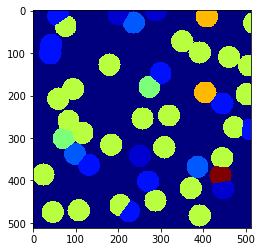

[ 0.  1.  2.  3.  7.  8. 10. 14.]
tensor([2889])


In [72]:
# Generator
np.random.seed()
train_set = Dataset(training_indexes, pseudo_image, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
# while True:
for x, y in train_loader:
    plt.imshow(np.transpose(x['image'][0].numpy(), (1, 2, 0))[..., 0], cmap='jet', interpolation='nearest')
    plt.show()
    print(np.unique(np.transpose(x['image'][0].numpy(), (1, 2, 0))[..., 0]))
    print(y)
    break

In [46]:
np.unique(pseudo_image[..., 0])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16.])

## 3) Create network

In [75]:
device = torch.device("cuda:0")
from torch.nn.modules import MSELoss
from utils_eval import NCESoftmaxLoss, NCECriterion

image_shape = PATCH_SIZE
n_genes = count_stat.shape[1]
n_data = len(training_indexes)
n_out_features = 50
imagenet = 'resnet101'

# NCE parameters

nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters
lr = 0.01   # ori 0.01
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(training_indexes, pseudo_image, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)
test_set = Dataset(testing_indexes, pseudo_image, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, n_image_channels=n_genes_for_image+10, 
               n_embedding_input=len(hue_order)+1, n_embedding_output=10, 
               imagenet=imagenet, genenet=[100, 50]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

Using cache found in /home2/swan15/.cache/torch/hub/pytorch_vision_v0.6.0


In [76]:
model_dir = "./models/Dataset_MERFISH"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

In [78]:
"""TO LOAD:"""
model_file = None
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

## 4) Train

In [79]:
import time
from scipy.stats import spearmanr

from utils_eval import AverageMeter

def train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device=torch.device("cuda:0")):
    """
    One epoch training
    """
    model.train()
    contrast.train()

    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()
    image_loss_meter = AverageMeter()
    gene_loss_meter = AverageMeter()
    image_prob_meter = AverageMeter()
    gene_prob_meter = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(train_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        out_image, out_gene = contrast(feat_image, feat_gene, index)
        
        # print("features:", feat_image, feat_gene, "\n")
        # print("outs: ", out_image, out_gene, "\n")
        
        image_loss = criterion_image(out_image)
        gene_loss = criterion_gene(out_gene)
        image_prob = out_image[:, 0].mean()
        gene_prob = out_gene[:, 0].mean()

        loss = image_loss + gene_loss

        # ===================backward=====================
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        torch.nn.utils.clip_grad_norm_(contrast.parameters(), gradient_clip)
        optimizer.step()

        # ===================meters=====================
        losses.update(loss.item(), batch_size)
        image_loss_meter.update(image_loss.item(), batch_size)
        image_prob_meter.update(image_prob.item(), batch_size)
        gene_loss_meter.update(gene_loss.item(), batch_size)
        gene_prob_meter.update(gene_prob.item(), batch_size)

        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()

        # print info
        if (idx + 1) % print_freq == 0:
            print('Epoch: [{0}][{1}/{2}]\t'
                  # 'BT {batch_time.val:.3f} ({batch_time.avg:.3f})\t'
                  # 'DT {data_time.val:.3f} ({data_time.avg:.3f})\t'
                  'loss {loss.val:.3f} ({loss.avg:.3f})\t'
                  'image_p {image_probs.val:.3f} ({image_probs.avg:.3f})\t'
                  'gene_p {gene_probs.val:.3f} ({gene_probs.avg:.3f})'.format(
                   epoch, idx + 1, len(train_loader), batch_time=batch_time,
                   data_time=data_time, 
                   loss=losses, 
                   image_probs=image_prob_meter,
                   gene_probs=gene_prob_meter))
            # print(out_image.shape)
            sys.stdout.flush()
            
        # ===================debug======================
        if np.isnan(image_prob_meter.val):
            print(list(model.parameters()))
            print(feat_image)
            print(feat_gene)
            print(out_image)
            
            raise Exception("Nan detected")
            break

    return losses.avg, image_loss_meter.avg, image_prob_meter.avg, gene_loss_meter.avg, gene_prob_meter.avg


def test(epoch, test_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device=torch.device("cuda:0")):
    """Testing"""
    model.eval()
    contrast.eval()

    batch_time = AverageMeter()
    data_time = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(test_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        with torch.no_grad():
            feat_image, feat_gene = model(data)
        
        # Append
        if idx == 0:
            feat_images = feat_image.cpu().numpy()
            feat_genes = feat_gene.cpu().numpy()
        else:
            feat_images = np.concatenate([feat_images, feat_image.cpu().numpy()])
            feat_genes = np.concatenate([feat_genes, feat_gene.cpu().numpy()])
        
        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()
        
    # Normalize & calculate correlation
    feat_images = feat_images / np.sum(feat_images ** 2, axis=1, keepdims=True) ** 0.5
    feat_genes = feat_genes / np.sum(feat_genes ** 2, axis=1, keepdims=True) ** 0.5
    corr = []
    for i in range(feat_images.shape[1]):
        corr.append(spearmanr(feat_images[:, i], feat_genes[:, i]).correlation)
    if epoch % 100 == 0:
        plt.hist(corr, bins=30)
        plt.show()
    print("Val epoch {}, average corr {}".format(epoch, np.average(corr)))

    return np.average(corr)

Epoch: [0][10/270]	loss 64.292 (75.054)	image_p 0.000 (0.008)	gene_p 0.013 (0.010)
Epoch: [0][20/270]	loss 63.698 (69.408)	image_p 0.001 (0.009)	gene_p 0.010 (0.010)
Epoch: [0][30/270]	loss 60.593 (66.759)	image_p 0.001 (0.009)	gene_p 0.010 (0.010)
Epoch: [0][40/270]	loss 57.969 (64.843)	image_p 0.002 (0.009)	gene_p 0.011 (0.010)
Epoch: [0][50/270]	loss 52.861 (62.677)	image_p 0.000 (0.009)	gene_p 0.006 (0.011)
Epoch: [0][60/270]	loss 42.020 (60.231)	image_p 0.086 (0.009)	gene_p 0.035 (0.011)
Epoch: [0][70/270]	loss 38.550 (57.482)	image_p 0.000 (0.010)	gene_p 0.053 (0.013)
Epoch: [0][80/270]	loss 36.500 (54.951)	image_p 0.001 (0.012)	gene_p 0.001 (0.014)
Epoch: [0][90/270]	loss 33.915 (52.778)	image_p 0.002 (0.012)	gene_p 0.015 (0.014)
Epoch: [0][100/270]	loss 35.714 (51.075)	image_p 0.003 (0.012)	gene_p 0.023 (0.014)
Epoch: [0][110/270]	loss 31.615 (49.571)	image_p 0.004 (0.012)	gene_p 0.000 (0.015)
Epoch: [0][120/270]	loss 35.976 (48.332)	image_p 0.002 (0.013)	gene_p 0.020 (0.015)
E

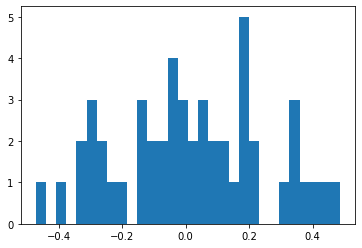

Val epoch 0, average corr 0.014069588494347324
Epoch: [1][10/270]	loss 35.641 (38.814)	image_p 0.029 (0.013)	gene_p 0.001 (0.007)
Epoch: [1][20/270]	loss 36.232 (37.115)	image_p 0.007 (0.016)	gene_p 0.005 (0.021)
Epoch: [1][30/270]	loss 36.927 (36.416)	image_p 0.000 (0.011)	gene_p 0.001 (0.018)
Epoch: [1][40/270]	loss 34.982 (35.623)	image_p 0.001 (0.012)	gene_p 0.002 (0.016)
Epoch: [1][50/270]	loss 32.202 (35.326)	image_p 0.014 (0.012)	gene_p 0.002 (0.013)
Epoch: [1][60/270]	loss 33.783 (34.980)	image_p 0.061 (0.013)	gene_p 0.003 (0.013)
Epoch: [1][70/270]	loss 33.682 (34.721)	image_p 0.042 (0.013)	gene_p 0.002 (0.013)
Epoch: [1][80/270]	loss 30.182 (34.411)	image_p 0.003 (0.014)	gene_p 0.004 (0.013)
Epoch: [1][90/270]	loss 31.615 (34.239)	image_p 0.019 (0.014)	gene_p 0.003 (0.012)
Epoch: [1][100/270]	loss 32.977 (33.947)	image_p 0.003 (0.015)	gene_p 0.004 (0.014)
Epoch: [1][110/270]	loss 33.333 (33.724)	image_p 0.001 (0.014)	gene_p 0.005 (0.014)
Epoch: [1][120/270]	loss 33.927 (33.49

Epoch: [4][160/270]	loss 29.642 (31.493)	image_p 0.000 (0.016)	gene_p 0.005 (0.018)
Epoch: [4][170/270]	loss 27.024 (31.240)	image_p 0.006 (0.016)	gene_p 0.009 (0.018)
Epoch: [4][180/270]	loss 25.762 (30.995)	image_p 0.006 (0.017)	gene_p 0.076 (0.020)
Epoch: [4][190/270]	loss 25.748 (30.757)	image_p 0.013 (0.018)	gene_p 0.106 (0.022)
Epoch: [4][200/270]	loss 24.831 (30.489)	image_p 0.045 (0.019)	gene_p 0.055 (0.023)
Epoch: [4][210/270]	loss 22.531 (30.194)	image_p 0.108 (0.020)	gene_p 0.133 (0.025)
Epoch: [4][220/270]	loss 25.413 (29.892)	image_p 0.013 (0.022)	gene_p 0.011 (0.027)
Epoch: [4][230/270]	loss 22.192 (29.580)	image_p 0.033 (0.024)	gene_p 0.129 (0.030)
Epoch: [4][240/270]	loss 21.992 (29.215)	image_p 0.045 (0.027)	gene_p 0.099 (0.035)
Epoch: [4][250/270]	loss 17.912 (28.817)	image_p 0.084 (0.030)	gene_p 0.234 (0.040)
Epoch: [4][260/270]	loss 11.251 (28.288)	image_p 0.305 (0.039)	gene_p 0.453 (0.048)
Epoch: [4][270/270]	loss 0.730 (27.624)	image_p 0.996 (0.055)	gene_p 0.987 (

Epoch: [8][40/270]	loss 33.042 (39.219)	image_p 0.000 (0.008)	gene_p 0.027 (0.017)
Epoch: [8][50/270]	loss 33.763 (37.970)	image_p 0.013 (0.008)	gene_p 0.050 (0.019)
Epoch: [8][60/270]	loss 30.798 (36.789)	image_p 0.015 (0.010)	gene_p 0.031 (0.022)
Epoch: [8][70/270]	loss 30.987 (35.977)	image_p 0.001 (0.010)	gene_p 0.030 (0.025)
Epoch: [8][80/270]	loss 31.093 (35.430)	image_p 0.002 (0.009)	gene_p 0.054 (0.024)
Epoch: [8][90/270]	loss 30.206 (34.799)	image_p 0.006 (0.010)	gene_p 0.002 (0.025)
Epoch: [8][100/270]	loss 30.246 (34.348)	image_p 0.000 (0.011)	gene_p 0.021 (0.025)
Epoch: [8][110/270]	loss 29.227 (33.981)	image_p 0.048 (0.011)	gene_p 0.053 (0.025)
Epoch: [8][120/270]	loss 30.290 (33.640)	image_p 0.001 (0.011)	gene_p 0.001 (0.025)
Epoch: [8][130/270]	loss 28.995 (33.325)	image_p 0.001 (0.011)	gene_p 0.057 (0.025)
Epoch: [8][140/270]	loss 28.817 (32.989)	image_p 0.065 (0.012)	gene_p 0.006 (0.026)
Epoch: [8][150/270]	loss 26.369 (32.652)	image_p 0.009 (0.013)	gene_p 0.072 (0.027

Epoch: [11][190/270]	loss 27.968 (30.652)	image_p 0.035 (0.025)	gene_p 0.047 (0.025)
Epoch: [11][200/270]	loss 24.590 (30.435)	image_p 0.161 (0.027)	gene_p 0.018 (0.026)
Epoch: [11][210/270]	loss 27.836 (30.214)	image_p 0.059 (0.027)	gene_p 0.010 (0.027)
Epoch: [11][220/270]	loss 24.479 (29.944)	image_p 0.089 (0.029)	gene_p 0.016 (0.028)
Epoch: [11][230/270]	loss 20.714 (29.634)	image_p 0.109 (0.032)	gene_p 0.068 (0.030)
Epoch: [11][240/270]	loss 19.693 (29.274)	image_p 0.138 (0.036)	gene_p 0.100 (0.032)
Epoch: [11][250/270]	loss 16.551 (28.844)	image_p 0.233 (0.040)	gene_p 0.260 (0.037)
Epoch: [11][260/270]	loss 12.433 (28.305)	image_p 0.395 (0.050)	gene_p 0.466 (0.045)
Epoch: [11][270/270]	loss 4.190 (27.670)	image_p 0.985 (0.067)	gene_p 0.838 (0.058)
Val epoch 11, average corr 0.3196578272027374
Epoch: [12][10/270]	loss 34.789 (37.335)	image_p 0.004 (0.012)	gene_p 0.001 (0.013)
Epoch: [12][20/270]	loss 36.936 (35.686)	image_p 0.000 (0.018)	gene_p 0.000 (0.008)
Epoch: [12][30/270]	lo

Epoch: [15][60/270]	loss 31.895 (36.888)	image_p 0.000 (0.008)	gene_p 0.035 (0.024)
Epoch: [15][70/270]	loss 31.264 (36.315)	image_p 0.023 (0.009)	gene_p 0.142 (0.025)
Epoch: [15][80/270]	loss 33.966 (35.880)	image_p 0.000 (0.009)	gene_p 0.056 (0.025)
Epoch: [15][90/270]	loss 31.194 (35.383)	image_p 0.000 (0.010)	gene_p 0.022 (0.027)
Epoch: [15][100/270]	loss 33.195 (34.985)	image_p 0.002 (0.009)	gene_p 0.004 (0.028)
Epoch: [15][110/270]	loss 25.635 (34.532)	image_p 0.003 (0.009)	gene_p 0.046 (0.028)
Epoch: [15][120/270]	loss 28.966 (34.202)	image_p 0.004 (0.009)	gene_p 0.074 (0.028)
Epoch: [15][130/270]	loss 29.373 (33.849)	image_p 0.002 (0.009)	gene_p 0.048 (0.031)
Epoch: [15][140/270]	loss 29.874 (33.569)	image_p 0.007 (0.009)	gene_p 0.011 (0.030)
Epoch: [15][150/270]	loss 28.101 (33.286)	image_p 0.050 (0.010)	gene_p 0.045 (0.030)
Epoch: [15][160/270]	loss 26.184 (33.041)	image_p 0.059 (0.010)	gene_p 0.050 (0.031)
Epoch: [15][170/270]	loss 24.862 (32.757)	image_p 0.014 (0.010)	gene_

...

Epoch: [85][240/270]	loss 19.119 (29.713)	image_p 0.137 (0.057)	gene_p 0.127 (0.052)
Epoch: [85][250/270]	loss 17.960 (29.190)	image_p 0.116 (0.063)	gene_p 0.193 (0.057)
Epoch: [85][260/270]	loss 12.438 (28.608)	image_p 0.329 (0.073)	gene_p 0.359 (0.066)
Epoch: [85][270/270]	loss 2.892 (27.936)	image_p 0.871 (0.090)	gene_p 0.935 (0.083)
Val epoch 85, average corr 0.5845687904157577
Epoch: [86][10/270]	loss 42.999 (44.758)	image_p 0.006 (0.023)	gene_p 0.009 (0.013)
Epoch: [86][20/270]	loss 38.738 (42.228)	image_p 0.000 (0.023)	gene_p 0.000 (0.030)
Epoch: [86][30/270]	loss 40.472 (40.986)	image_p 0.000 (0.020)	gene_p 0.001 (0.022)
Epoch: [86][40/270]	loss 37.133 (40.093)	image_p 0.002 (0.016)	gene_p 0.006 (0.020)
Epoch: [86][50/270]	loss 37.086 (39.413)	image_p 0.000 (0.013)	gene_p 0.002 (0.021)
Epoch: [86][60/270]	loss 40.143 (39.118)	image_p 0.027 (0.012)	gene_p 0.098 (0.022)
Epoch: [86][70/270]	loss 38.963 (38.824)	image_p 0.000 (0.011)	gene_p 0.000 (0.022)
Epoch: [86][80/270]	loss 38

Epoch: [89][110/270]	loss 31.565 (35.087)	image_p 0.040 (0.033)	gene_p 0.005 (0.030)
Epoch: [89][120/270]	loss 33.196 (34.713)	image_p 0.020 (0.033)	gene_p 0.004 (0.030)
Epoch: [89][130/270]	loss 30.066 (34.304)	image_p 0.032 (0.033)	gene_p 0.047 (0.030)
Epoch: [89][140/270]	loss 30.226 (33.960)	image_p 0.008 (0.033)	gene_p 0.001 (0.031)
Epoch: [89][150/270]	loss 28.672 (33.532)	image_p 0.036 (0.035)	gene_p 0.046 (0.033)
Epoch: [89][160/270]	loss 28.355 (33.155)	image_p 0.050 (0.036)	gene_p 0.081 (0.034)
Epoch: [89][170/270]	loss 24.968 (32.710)	image_p 0.052 (0.038)	gene_p 0.069 (0.038)
Epoch: [89][180/270]	loss 24.815 (32.249)	image_p 0.068 (0.042)	gene_p 0.045 (0.040)
Epoch: [89][190/270]	loss 25.646 (31.842)	image_p 0.067 (0.044)	gene_p 0.045 (0.043)
Epoch: [89][200/270]	loss 24.472 (31.419)	image_p 0.089 (0.047)	gene_p 0.098 (0.045)
Epoch: [89][210/270]	loss 22.588 (31.060)	image_p 0.214 (0.049)	gene_p 0.071 (0.047)
Epoch: [89][220/270]	loss 19.408 (30.617)	image_p 0.140 (0.052)	g

Epoch: [92][250/270]	loss 15.470 (26.592)	image_p 0.279 (0.061)	gene_p 0.144 (0.063)
Epoch: [92][260/270]	loss 9.357 (26.058)	image_p 0.415 (0.071)	gene_p 0.474 (0.073)
Epoch: [92][270/270]	loss 1.464 (25.402)	image_p 0.953 (0.090)	gene_p 0.997 (0.092)
Val epoch 92, average corr 0.46622294681507326
Epoch: [93][10/270]	loss 30.401 (35.282)	image_p 0.056 (0.024)	gene_p 0.054 (0.029)
Epoch: [93][20/270]	loss 35.205 (33.881)	image_p 0.023 (0.024)	gene_p 0.020 (0.026)
Epoch: [93][30/270]	loss 30.634 (33.817)	image_p 0.004 (0.023)	gene_p 0.002 (0.023)
Epoch: [93][40/270]	loss 28.988 (33.249)	image_p 0.072 (0.025)	gene_p 0.015 (0.024)
Epoch: [93][50/270]	loss 31.670 (32.761)	image_p 0.122 (0.029)	gene_p 0.059 (0.027)
Epoch: [93][60/270]	loss 30.827 (32.613)	image_p 0.028 (0.030)	gene_p 0.018 (0.028)
Epoch: [93][70/270]	loss 27.488 (32.391)	image_p 0.086 (0.031)	gene_p 0.051 (0.030)
Epoch: [93][80/270]	loss 29.531 (32.088)	image_p 0.072 (0.031)	gene_p 0.046 (0.032)
Epoch: [93][90/270]	loss 30.

Epoch: [96][120/270]	loss 27.549 (31.533)	image_p 0.007 (0.039)	gene_p 0.011 (0.043)
Epoch: [96][130/270]	loss 27.806 (31.225)	image_p 0.053 (0.042)	gene_p 0.045 (0.043)
Epoch: [96][140/270]	loss 27.076 (30.960)	image_p 0.054 (0.043)	gene_p 0.033 (0.042)
Epoch: [96][150/270]	loss 27.772 (30.694)	image_p 0.060 (0.044)	gene_p 0.030 (0.042)
Epoch: [96][160/270]	loss 29.715 (30.504)	image_p 0.038 (0.046)	gene_p 0.036 (0.044)
Epoch: [96][170/270]	loss 25.043 (30.208)	image_p 0.035 (0.048)	gene_p 0.075 (0.046)
Epoch: [96][180/270]	loss 24.094 (29.928)	image_p 0.094 (0.050)	gene_p 0.199 (0.048)
Epoch: [96][190/270]	loss 25.113 (29.603)	image_p 0.079 (0.051)	gene_p 0.035 (0.049)
Epoch: [96][200/270]	loss 21.045 (29.288)	image_p 0.081 (0.054)	gene_p 0.139 (0.052)
Epoch: [96][210/270]	loss 24.697 (28.942)	image_p 0.107 (0.058)	gene_p 0.106 (0.055)
Epoch: [96][220/270]	loss 23.111 (28.576)	image_p 0.103 (0.062)	gene_p 0.024 (0.059)
Epoch: [96][230/270]	loss 18.343 (28.171)	image_p 0.165 (0.066)	g

Epoch: [99][270/270]	loss 4.991 (25.850)	image_p 0.944 (0.098)	gene_p 0.833 (0.092)
Val epoch 99, average corr 0.42072423139950743
Epoch: [100][10/270]	loss 31.876 (32.800)	image_p 0.027 (0.024)	gene_p 0.053 (0.040)
Epoch: [100][20/270]	loss 33.983 (32.296)	image_p 0.031 (0.026)	gene_p 0.023 (0.041)
Epoch: [100][30/270]	loss 31.810 (32.241)	image_p 0.018 (0.022)	gene_p 0.031 (0.031)
Epoch: [100][40/270]	loss 29.613 (32.082)	image_p 0.006 (0.021)	gene_p 0.006 (0.034)
Epoch: [100][50/270]	loss 30.359 (31.778)	image_p 0.079 (0.023)	gene_p 0.087 (0.034)
Epoch: [100][60/270]	loss 28.063 (31.640)	image_p 0.059 (0.025)	gene_p 0.078 (0.035)
Epoch: [100][70/270]	loss 29.646 (31.259)	image_p 0.016 (0.027)	gene_p 0.007 (0.036)
Epoch: [100][80/270]	loss 30.989 (31.266)	image_p 0.051 (0.027)	gene_p 0.009 (0.035)
Epoch: [100][90/270]	loss 29.689 (31.166)	image_p 0.020 (0.027)	gene_p 0.041 (0.036)
Epoch: [100][100/270]	loss 29.921 (31.057)	image_p 0.059 (0.027)	gene_p 0.082 (0.035)
Epoch: [100][110/2

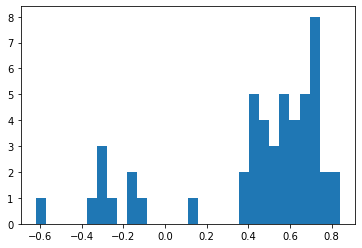

Val epoch 100, average corr 0.42865295227101735
Saving model...
Epoch: [101][10/270]	loss 41.013 (39.532)	image_p 0.014 (0.025)	gene_p 0.023 (0.046)
Epoch: [101][20/270]	loss 37.542 (38.752)	image_p 0.001 (0.028)	gene_p 0.006 (0.033)
Epoch: [101][30/270]	loss 33.053 (37.221)	image_p 0.007 (0.025)	gene_p 0.003 (0.037)
Epoch: [101][40/270]	loss 32.217 (36.481)	image_p 0.081 (0.030)	gene_p 0.080 (0.038)
Epoch: [101][50/270]	loss 35.006 (35.913)	image_p 0.036 (0.030)	gene_p 0.036 (0.038)
Epoch: [101][60/270]	loss 34.401 (35.499)	image_p 0.012 (0.029)	gene_p 0.002 (0.036)
Epoch: [101][70/270]	loss 30.446 (35.046)	image_p 0.070 (0.029)	gene_p 0.047 (0.041)
Epoch: [101][80/270]	loss 32.600 (34.711)	image_p 0.066 (0.030)	gene_p 0.025 (0.042)
Epoch: [101][90/270]	loss 29.084 (34.344)	image_p 0.070 (0.030)	gene_p 0.064 (0.044)
Epoch: [101][100/270]	loss 36.134 (34.046)	image_p 0.010 (0.032)	gene_p 0.074 (0.044)
Epoch: [101][110/270]	loss 29.488 (33.769)	image_p 0.045 (0.033)	gene_p 0.061 (0.045)

Epoch: [104][140/270]	loss 25.381 (31.082)	image_p 0.047 (0.045)	gene_p 0.117 (0.038)
Epoch: [104][150/270]	loss 26.943 (30.767)	image_p 0.022 (0.046)	gene_p 0.010 (0.039)
Epoch: [104][160/270]	loss 25.014 (30.481)	image_p 0.031 (0.047)	gene_p 0.100 (0.041)
Epoch: [104][170/270]	loss 25.933 (30.137)	image_p 0.070 (0.048)	gene_p 0.066 (0.043)
Epoch: [104][180/270]	loss 25.653 (29.855)	image_p 0.076 (0.050)	gene_p 0.081 (0.045)
Epoch: [104][190/270]	loss 21.911 (29.485)	image_p 0.157 (0.053)	gene_p 0.222 (0.048)
Epoch: [104][200/270]	loss 21.347 (29.183)	image_p 0.149 (0.055)	gene_p 0.123 (0.050)
Epoch: [104][210/270]	loss 21.344 (28.855)	image_p 0.116 (0.058)	gene_p 0.117 (0.051)
Epoch: [104][220/270]	loss 20.524 (28.460)	image_p 0.224 (0.063)	gene_p 0.146 (0.056)
Epoch: [104][230/270]	loss 20.809 (28.064)	image_p 0.138 (0.068)	gene_p 0.098 (0.061)
Epoch: [104][240/270]	loss 14.285 (27.585)	image_p 0.301 (0.075)	gene_p 0.242 (0.066)
Epoch: [104][250/270]	loss 14.190 (27.118)	image_p 0.1

Epoch: [107][270/270]	loss 11.214 (25.555)	image_p 0.700 (0.112)	gene_p 0.669 (0.111)
Val epoch 107, average corr 0.4257314406127336
Epoch: [108][10/270]	loss 35.156 (36.227)	image_p 0.009 (0.022)	gene_p 0.029 (0.033)
Epoch: [108][20/270]	loss 29.703 (35.590)	image_p 0.074 (0.022)	gene_p 0.063 (0.034)
Epoch: [108][30/270]	loss 30.553 (34.552)	image_p 0.065 (0.034)	gene_p 0.030 (0.032)
Epoch: [108][40/270]	loss 32.495 (34.035)	image_p 0.004 (0.032)	gene_p 0.040 (0.033)
Epoch: [108][50/270]	loss 29.495 (33.176)	image_p 0.056 (0.033)	gene_p 0.061 (0.038)
Epoch: [108][60/270]	loss 31.794 (32.759)	image_p 0.024 (0.035)	gene_p 0.090 (0.039)
Epoch: [108][70/270]	loss 27.457 (32.317)	image_p 0.080 (0.038)	gene_p 0.099 (0.043)
Epoch: [108][80/270]	loss 29.798 (32.083)	image_p 0.051 (0.037)	gene_p 0.062 (0.043)
Epoch: [108][90/270]	loss 29.180 (31.609)	image_p 0.004 (0.039)	gene_p 0.104 (0.046)
Epoch: [108][100/270]	loss 28.906 (31.350)	image_p 0.021 (0.039)	gene_p 0.021 (0.047)
Epoch: [108][110

Epoch: [111][130/270]	loss 27.155 (30.833)	image_p 0.018 (0.046)	gene_p 0.034 (0.043)
Epoch: [111][140/270]	loss 28.052 (30.545)	image_p 0.039 (0.048)	gene_p 0.017 (0.044)
Epoch: [111][150/270]	loss 28.568 (30.184)	image_p 0.075 (0.049)	gene_p 0.070 (0.045)
Epoch: [111][160/270]	loss 25.542 (29.877)	image_p 0.042 (0.051)	gene_p 0.012 (0.045)
Epoch: [111][170/270]	loss 23.510 (29.586)	image_p 0.160 (0.052)	gene_p 0.151 (0.048)
Epoch: [111][180/270]	loss 24.666 (29.296)	image_p 0.132 (0.054)	gene_p 0.170 (0.051)
Epoch: [111][190/270]	loss 23.519 (28.982)	image_p 0.149 (0.056)	gene_p 0.097 (0.053)
Epoch: [111][200/270]	loss 21.841 (28.596)	image_p 0.078 (0.059)	gene_p 0.195 (0.057)
Epoch: [111][210/270]	loss 19.538 (28.252)	image_p 0.233 (0.064)	gene_p 0.254 (0.061)
Epoch: [111][220/270]	loss 19.252 (27.885)	image_p 0.152 (0.067)	gene_p 0.097 (0.065)
Epoch: [111][230/270]	loss 19.351 (27.478)	image_p 0.158 (0.073)	gene_p 0.208 (0.070)
Epoch: [111][240/270]	loss 14.147 (27.065)	image_p 0.3

Epoch: [114][260/270]	loss 8.797 (25.633)	image_p 0.580 (0.104)	gene_p 0.442 (0.101)
Epoch: [114][270/270]	loss 1.420 (24.946)	image_p 0.985 (0.124)	gene_p 0.863 (0.119)
Val epoch 114, average corr 0.4807888709925359
Epoch: [115][10/270]	loss 32.649 (33.793)	image_p 0.054 (0.040)	gene_p 0.063 (0.042)
Epoch: [115][20/270]	loss 30.883 (32.833)	image_p 0.102 (0.049)	gene_p 0.000 (0.034)
Epoch: [115][30/270]	loss 32.819 (32.771)	image_p 0.059 (0.046)	gene_p 0.000 (0.029)
Epoch: [115][40/270]	loss 33.646 (32.982)	image_p 0.008 (0.039)	gene_p 0.001 (0.024)
Epoch: [115][50/270]	loss 32.802 (32.956)	image_p 0.054 (0.039)	gene_p 0.000 (0.021)
Epoch: [115][60/270]	loss 34.020 (32.567)	image_p 0.005 (0.041)	gene_p 0.038 (0.019)
Epoch: [115][70/270]	loss 35.194 (32.149)	image_p 0.039 (0.046)	gene_p 0.001 (0.019)
Epoch: [115][80/270]	loss 29.378 (31.821)	image_p 0.112 (0.050)	gene_p 0.009 (0.018)
Epoch: [115][90/270]	loss 29.579 (31.794)	image_p 0.064 (0.050)	gene_p 0.005 (0.017)
Epoch: [115][100/2

...

Epoch: [184][210/270]	loss 17.578 (23.647)	image_p 0.201 (0.139)	gene_p 0.272 (0.115)
Epoch: [184][220/270]	loss 20.877 (23.349)	image_p 0.187 (0.148)	gene_p 0.159 (0.119)
Epoch: [184][230/270]	loss 13.566 (23.041)	image_p 0.439 (0.157)	gene_p 0.253 (0.124)
Epoch: [184][240/270]	loss 13.721 (22.706)	image_p 0.395 (0.167)	gene_p 0.229 (0.131)
Epoch: [184][250/270]	loss 17.013 (22.378)	image_p 0.433 (0.176)	gene_p 0.192 (0.137)
Epoch: [184][260/270]	loss 8.530 (21.948)	image_p 0.553 (0.190)	gene_p 0.635 (0.147)
Epoch: [184][270/270]	loss 6.260 (21.453)	image_p 0.988 (0.209)	gene_p 0.539 (0.162)
Val epoch 184, average corr 0.6355148566893751
Epoch: [185][10/270]	loss 28.533 (30.777)	image_p 0.086 (0.067)	gene_p 0.041 (0.062)
Epoch: [185][20/270]	loss 28.206 (30.063)	image_p 0.053 (0.074)	gene_p 0.065 (0.071)
Epoch: [185][30/270]	loss 25.220 (29.159)	image_p 0.094 (0.088)	gene_p 0.011 (0.076)
Epoch: [185][40/270]	loss 27.486 (28.539)	image_p 0.113 (0.088)	gene_p 0.130 (0.084)
Epoch: [185][

Epoch: [188][70/270]	loss 26.827 (28.898)	image_p 0.063 (0.094)	gene_p 0.096 (0.102)
Epoch: [188][80/270]	loss 25.322 (28.591)	image_p 0.133 (0.093)	gene_p 0.099 (0.104)
Epoch: [188][90/270]	loss 25.307 (28.280)	image_p 0.027 (0.091)	gene_p 0.073 (0.107)
Epoch: [188][100/270]	loss 26.994 (28.078)	image_p 0.101 (0.090)	gene_p 0.202 (0.111)
Epoch: [188][110/270]	loss 25.723 (27.833)	image_p 0.089 (0.089)	gene_p 0.110 (0.114)
Epoch: [188][120/270]	loss 23.201 (27.536)	image_p 0.046 (0.088)	gene_p 0.129 (0.120)
Epoch: [188][130/270]	loss 24.757 (27.489)	image_p 0.047 (0.086)	gene_p 0.143 (0.121)
Epoch: [188][140/270]	loss 26.600 (27.400)	image_p 0.048 (0.084)	gene_p 0.150 (0.123)
Epoch: [188][150/270]	loss 21.868 (27.110)	image_p 0.069 (0.085)	gene_p 0.195 (0.127)
Epoch: [188][160/270]	loss 24.227 (26.913)	image_p 0.163 (0.087)	gene_p 0.221 (0.130)
Epoch: [188][170/270]	loss 22.082 (26.722)	image_p 0.247 (0.090)	gene_p 0.084 (0.131)
Epoch: [188][180/270]	loss 20.919 (26.498)	image_p 0.161 

Epoch: [191][200/270]	loss 13.185 (22.692)	image_p 0.539 (0.167)	gene_p 0.334 (0.165)
Epoch: [191][210/270]	loss 19.306 (22.455)	image_p 0.270 (0.170)	gene_p 0.196 (0.168)
Epoch: [191][220/270]	loss 16.637 (22.149)	image_p 0.417 (0.177)	gene_p 0.164 (0.173)
Epoch: [191][230/270]	loss 12.644 (21.822)	image_p 0.364 (0.185)	gene_p 0.417 (0.179)
Epoch: [191][240/270]	loss 12.157 (21.431)	image_p 0.361 (0.194)	gene_p 0.524 (0.188)
Epoch: [191][250/270]	loss 9.347 (21.042)	image_p 0.564 (0.205)	gene_p 0.523 (0.198)
Epoch: [191][260/270]	loss 10.355 (20.601)	image_p 0.608 (0.221)	gene_p 0.561 (0.210)
Epoch: [191][270/270]	loss 2.743 (20.105)	image_p 0.998 (0.240)	gene_p 0.843 (0.226)
Val epoch 191, average corr 0.642157698372618
Epoch: [192][10/270]	loss 27.321 (28.352)	image_p 0.109 (0.105)	gene_p 0.236 (0.107)
Epoch: [192][20/270]	loss 28.070 (28.435)	image_p 0.100 (0.097)	gene_p 0.086 (0.108)
Epoch: [192][30/270]	loss 22.300 (27.396)	image_p 0.209 (0.107)	gene_p 0.147 (0.110)
Epoch: [192][

Epoch: [195][60/270]	loss 25.250 (27.288)	image_p 0.117 (0.112)	gene_p 0.092 (0.092)
Epoch: [195][70/270]	loss 20.785 (26.891)	image_p 0.189 (0.117)	gene_p 0.269 (0.099)
Epoch: [195][80/270]	loss 21.701 (26.622)	image_p 0.161 (0.118)	gene_p 0.149 (0.101)
Epoch: [195][90/270]	loss 23.979 (26.430)	image_p 0.102 (0.118)	gene_p 0.179 (0.106)
Epoch: [195][100/270]	loss 28.714 (26.285)	image_p 0.110 (0.118)	gene_p 0.103 (0.108)
Epoch: [195][110/270]	loss 27.115 (26.091)	image_p 0.019 (0.121)	gene_p 0.218 (0.110)
Epoch: [195][120/270]	loss 22.358 (25.895)	image_p 0.176 (0.125)	gene_p 0.050 (0.110)
Epoch: [195][130/270]	loss 24.616 (25.721)	image_p 0.050 (0.127)	gene_p 0.095 (0.110)
Epoch: [195][140/270]	loss 21.581 (25.458)	image_p 0.281 (0.131)	gene_p 0.163 (0.114)
Epoch: [195][150/270]	loss 20.715 (25.286)	image_p 0.216 (0.134)	gene_p 0.113 (0.115)
Epoch: [195][160/270]	loss 18.892 (25.078)	image_p 0.148 (0.139)	gene_p 0.131 (0.117)
Epoch: [195][170/270]	loss 16.440 (24.778)	image_p 0.368 (

Epoch: [198][200/270]	loss 18.136 (23.331)	image_p 0.404 (0.148)	gene_p 0.311 (0.169)
Epoch: [198][210/270]	loss 14.814 (22.992)	image_p 0.278 (0.153)	gene_p 0.218 (0.175)
Epoch: [198][220/270]	loss 14.837 (22.654)	image_p 0.247 (0.158)	gene_p 0.470 (0.181)
Epoch: [198][230/270]	loss 13.089 (22.248)	image_p 0.272 (0.168)	gene_p 0.533 (0.189)
Epoch: [198][240/270]	loss 10.846 (21.821)	image_p 0.502 (0.179)	gene_p 0.535 (0.200)
Epoch: [198][250/270]	loss 9.164 (21.355)	image_p 0.520 (0.192)	gene_p 0.595 (0.212)
Epoch: [198][260/270]	loss 5.745 (20.828)	image_p 0.580 (0.208)	gene_p 0.708 (0.226)
Epoch: [198][270/270]	loss 4.030 (20.274)	image_p 0.963 (0.227)	gene_p 0.783 (0.246)
Val epoch 198, average corr 0.6017761035588033
Epoch: [199][10/270]	loss 22.247 (27.110)	image_p 0.109 (0.114)	gene_p 0.229 (0.105)
Epoch: [199][20/270]	loss 27.492 (27.497)	image_p 0.083 (0.126)	gene_p 0.039 (0.095)
Epoch: [199][30/270]	loss 24.912 (26.985)	image_p 0.119 (0.127)	gene_p 0.218 (0.101)
Epoch: [199][

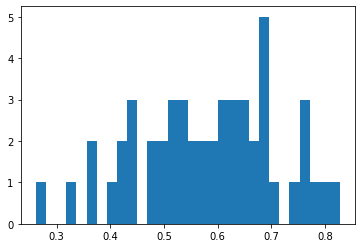

Val epoch 200, average corr 0.5797576963113361
Saving model...
Epoch: [201][10/270]	loss 24.076 (24.593)	image_p 0.202 (0.135)	gene_p 0.100 (0.136)
Epoch: [201][20/270]	loss 24.226 (24.524)	image_p 0.091 (0.134)	gene_p 0.152 (0.135)
Epoch: [201][30/270]	loss 25.800 (24.375)	image_p 0.124 (0.129)	gene_p 0.077 (0.124)
Epoch: [201][40/270]	loss 25.541 (24.620)	image_p 0.192 (0.133)	gene_p 0.063 (0.121)
Epoch: [201][50/270]	loss 24.930 (24.579)	image_p 0.135 (0.131)	gene_p 0.154 (0.126)
Epoch: [201][60/270]	loss 20.502 (24.392)	image_p 0.236 (0.136)	gene_p 0.126 (0.123)
Epoch: [201][70/270]	loss 21.225 (24.206)	image_p 0.241 (0.140)	gene_p 0.223 (0.125)
Epoch: [201][80/270]	loss 22.223 (24.094)	image_p 0.226 (0.141)	gene_p 0.121 (0.128)
Epoch: [201][90/270]	loss 21.769 (23.649)	image_p 0.214 (0.147)	gene_p 0.170 (0.141)
Epoch: [201][100/270]	loss 17.031 (23.274)	image_p 0.255 (0.154)	gene_p 0.264 (0.147)
Epoch: [201][110/270]	loss 21.676 (23.091)	image_p 0.101 (0.155)	gene_p 0.211 (0.149)


Epoch: [204][140/270]	loss 25.277 (24.205)	image_p 0.072 (0.138)	gene_p 0.060 (0.132)
Epoch: [204][150/270]	loss 19.464 (23.979)	image_p 0.263 (0.140)	gene_p 0.096 (0.135)
Epoch: [204][160/270]	loss 17.547 (23.690)	image_p 0.238 (0.145)	gene_p 0.197 (0.140)
Epoch: [204][170/270]	loss 21.599 (23.437)	image_p 0.112 (0.149)	gene_p 0.139 (0.145)
Epoch: [204][180/270]	loss 20.372 (23.184)	image_p 0.190 (0.156)	gene_p 0.181 (0.148)
Epoch: [204][190/270]	loss 15.127 (22.964)	image_p 0.339 (0.162)	gene_p 0.337 (0.152)
Epoch: [204][200/270]	loss 14.995 (22.704)	image_p 0.323 (0.165)	gene_p 0.406 (0.158)
Epoch: [204][210/270]	loss 16.128 (22.432)	image_p 0.303 (0.171)	gene_p 0.188 (0.163)
Epoch: [204][220/270]	loss 18.976 (22.138)	image_p 0.439 (0.178)	gene_p 0.179 (0.169)
Epoch: [204][230/270]	loss 12.466 (21.815)	image_p 0.353 (0.184)	gene_p 0.464 (0.177)
Epoch: [204][240/270]	loss 10.771 (21.425)	image_p 0.519 (0.193)	gene_p 0.482 (0.188)
Epoch: [204][250/270]	loss 11.571 (21.042)	image_p 0.3

Val epoch 207, average corr 0.647816741731683
Epoch: [208][10/270]	loss 27.501 (25.150)	image_p 0.134 (0.137)	gene_p 0.053 (0.115)
Epoch: [208][20/270]	loss 21.446 (24.858)	image_p 0.217 (0.144)	gene_p 0.253 (0.112)
Epoch: [208][30/270]	loss 23.357 (24.676)	image_p 0.201 (0.144)	gene_p 0.113 (0.129)
Epoch: [208][40/270]	loss 26.177 (24.587)	image_p 0.097 (0.135)	gene_p 0.186 (0.135)
Epoch: [208][50/270]	loss 23.188 (24.051)	image_p 0.138 (0.135)	gene_p 0.131 (0.143)
Epoch: [208][60/270]	loss 22.093 (24.213)	image_p 0.176 (0.136)	gene_p 0.198 (0.140)
Epoch: [208][70/270]	loss 25.430 (24.024)	image_p 0.141 (0.140)	gene_p 0.156 (0.141)
Epoch: [208][80/270]	loss 25.000 (23.990)	image_p 0.100 (0.143)	gene_p 0.138 (0.142)
Epoch: [208][90/270]	loss 21.338 (23.888)	image_p 0.123 (0.144)	gene_p 0.254 (0.144)
Epoch: [208][100/270]	loss 22.955 (23.676)	image_p 0.139 (0.145)	gene_p 0.197 (0.151)
Epoch: [208][110/270]	loss 23.332 (23.427)	image_p 0.151 (0.150)	gene_p 0.169 (0.157)
Epoch: [208][120/

Epoch: [211][140/270]	loss 19.602 (21.939)	image_p 0.168 (0.175)	gene_p 0.283 (0.183)
Epoch: [211][150/270]	loss 19.953 (21.770)	image_p 0.182 (0.179)	gene_p 0.281 (0.186)
Epoch: [211][160/270]	loss 18.586 (21.535)	image_p 0.234 (0.180)	gene_p 0.258 (0.190)
Epoch: [211][170/270]	loss 12.592 (21.312)	image_p 0.467 (0.186)	gene_p 0.402 (0.193)
Epoch: [211][180/270]	loss 20.200 (21.124)	image_p 0.276 (0.189)	gene_p 0.191 (0.199)
Epoch: [211][190/270]	loss 14.601 (20.907)	image_p 0.371 (0.195)	gene_p 0.349 (0.204)
Epoch: [211][200/270]	loss 17.546 (20.669)	image_p 0.167 (0.201)	gene_p 0.421 (0.209)
Epoch: [211][210/270]	loss 16.537 (20.482)	image_p 0.286 (0.205)	gene_p 0.395 (0.215)
Epoch: [211][220/270]	loss 13.332 (20.252)	image_p 0.322 (0.210)	gene_p 0.591 (0.225)
Epoch: [211][230/270]	loss 10.551 (20.019)	image_p 0.456 (0.217)	gene_p 0.446 (0.233)
Epoch: [211][240/270]	loss 10.825 (19.788)	image_p 0.431 (0.222)	gene_p 0.648 (0.240)
Epoch: [211][250/270]	loss 12.603 (19.482)	image_p 0.3

Val epoch 214, average corr 0.6028086512001815
Epoch: [215][10/270]	loss 26.291 (24.016)	image_p 0.180 (0.154)	gene_p 0.073 (0.161)
Epoch: [215][20/270]	loss 23.664 (24.459)	image_p 0.166 (0.153)	gene_p 0.165 (0.157)
Epoch: [215][30/270]	loss 25.169 (24.316)	image_p 0.069 (0.151)	gene_p 0.077 (0.149)
Epoch: [215][40/270]	loss 19.618 (23.840)	image_p 0.198 (0.158)	gene_p 0.109 (0.147)
Epoch: [215][50/270]	loss 23.244 (23.672)	image_p 0.145 (0.162)	gene_p 0.149 (0.148)
Epoch: [215][60/270]	loss 21.735 (23.464)	image_p 0.179 (0.162)	gene_p 0.122 (0.148)
Epoch: [215][70/270]	loss 18.555 (23.329)	image_p 0.205 (0.162)	gene_p 0.347 (0.151)
Epoch: [215][80/270]	loss 19.194 (23.055)	image_p 0.263 (0.169)	gene_p 0.194 (0.155)
Epoch: [215][90/270]	loss 21.759 (22.891)	image_p 0.110 (0.170)	gene_p 0.175 (0.155)
Epoch: [215][100/270]	loss 17.644 (22.678)	image_p 0.182 (0.173)	gene_p 0.240 (0.160)
Epoch: [215][110/270]	loss 20.123 (22.436)	image_p 0.283 (0.176)	gene_p 0.209 (0.163)
Epoch: [215][120

...

Epoch: [284][250/270]	loss 7.601 (15.104)	image_p 0.702 (0.369)	gene_p 0.626 (0.338)
Epoch: [284][260/270]	loss 3.249 (14.820)	image_p 0.794 (0.381)	gene_p 0.876 (0.349)
Epoch: [284][270/270]	loss 2.540 (14.457)	image_p 0.781 (0.396)	gene_p 0.875 (0.363)
Val epoch 284, average corr 0.707547229121791
Epoch: [285][10/270]	loss 20.577 (19.475)	image_p 0.108 (0.214)	gene_p 0.207 (0.254)
Epoch: [285][20/270]	loss 19.294 (18.832)	image_p 0.121 (0.234)	gene_p 0.165 (0.249)
Epoch: [285][30/270]	loss 14.468 (18.658)	image_p 0.448 (0.250)	gene_p 0.334 (0.247)
Epoch: [285][40/270]	loss 14.486 (18.552)	image_p 0.300 (0.245)	gene_p 0.393 (0.256)
Epoch: [285][50/270]	loss 14.672 (18.141)	image_p 0.386 (0.254)	gene_p 0.327 (0.263)
Epoch: [285][60/270]	loss 16.596 (17.918)	image_p 0.189 (0.260)	gene_p 0.366 (0.272)
Epoch: [285][70/270]	loss 18.198 (17.777)	image_p 0.270 (0.261)	gene_p 0.325 (0.276)
Epoch: [285][80/270]	loss 17.202 (17.537)	image_p 0.235 (0.268)	gene_p 0.256 (0.288)
Epoch: [285][90/270

Epoch: [288][110/270]	loss 17.445 (20.362)	image_p 0.249 (0.253)	gene_p 0.122 (0.215)
Epoch: [288][120/270]	loss 18.873 (20.218)	image_p 0.264 (0.254)	gene_p 0.169 (0.214)
Epoch: [288][130/270]	loss 20.084 (20.098)	image_p 0.352 (0.258)	gene_p 0.190 (0.214)
Epoch: [288][140/270]	loss 15.962 (19.994)	image_p 0.335 (0.261)	gene_p 0.324 (0.214)
Epoch: [288][150/270]	loss 18.950 (19.871)	image_p 0.351 (0.264)	gene_p 0.217 (0.215)
Epoch: [288][160/270]	loss 18.115 (19.747)	image_p 0.278 (0.270)	gene_p 0.327 (0.218)
Epoch: [288][170/270]	loss 16.884 (19.631)	image_p 0.368 (0.276)	gene_p 0.376 (0.219)
Epoch: [288][180/270]	loss 16.032 (19.476)	image_p 0.296 (0.282)	gene_p 0.331 (0.223)
Epoch: [288][190/270]	loss 13.424 (19.290)	image_p 0.560 (0.287)	gene_p 0.327 (0.227)
Epoch: [288][200/270]	loss 15.077 (19.137)	image_p 0.405 (0.292)	gene_p 0.318 (0.232)
Epoch: [288][210/270]	loss 16.539 (18.940)	image_p 0.400 (0.299)	gene_p 0.330 (0.238)
Epoch: [288][220/270]	loss 18.683 (18.789)	image_p 0.3

Epoch: [291][240/270]	loss 8.212 (13.935)	image_p 0.666 (0.388)	gene_p 0.572 (0.383)
Epoch: [291][250/270]	loss 4.561 (13.708)	image_p 0.836 (0.397)	gene_p 0.795 (0.392)
Epoch: [291][260/270]	loss 5.894 (13.458)	image_p 0.790 (0.409)	gene_p 0.604 (0.401)
Epoch: [291][270/270]	loss 5.818 (13.191)	image_p 0.953 (0.421)	gene_p 0.538 (0.411)
Val epoch 291, average corr 0.701901841755388
Epoch: [292][10/270]	loss 14.808 (17.539)	image_p 0.315 (0.238)	gene_p 0.146 (0.245)
Epoch: [292][20/270]	loss 17.065 (18.062)	image_p 0.403 (0.250)	gene_p 0.275 (0.241)
Epoch: [292][30/270]	loss 18.081 (18.465)	image_p 0.260 (0.248)	gene_p 0.381 (0.240)
Epoch: [292][40/270]	loss 10.678 (17.985)	image_p 0.376 (0.258)	gene_p 0.436 (0.261)
Epoch: [292][50/270]	loss 18.599 (17.647)	image_p 0.164 (0.275)	gene_p 0.295 (0.261)
Epoch: [292][60/270]	loss 15.971 (17.281)	image_p 0.403 (0.288)	gene_p 0.142 (0.264)
Epoch: [292][70/270]	loss 20.838 (17.097)	image_p 0.195 (0.291)	gene_p 0.275 (0.267)
Epoch: [292][80/270

Epoch: [295][100/270]	loss 17.905 (18.195)	image_p 0.400 (0.318)	gene_p 0.157 (0.231)
Epoch: [295][110/270]	loss 14.996 (17.851)	image_p 0.367 (0.327)	gene_p 0.304 (0.236)
Epoch: [295][120/270]	loss 13.898 (17.546)	image_p 0.386 (0.333)	gene_p 0.353 (0.244)
Epoch: [295][130/270]	loss 15.663 (17.242)	image_p 0.417 (0.344)	gene_p 0.294 (0.251)
Epoch: [295][140/270]	loss 11.494 (16.953)	image_p 0.380 (0.354)	gene_p 0.374 (0.257)
Epoch: [295][150/270]	loss 17.534 (16.753)	image_p 0.409 (0.361)	gene_p 0.299 (0.262)
Epoch: [295][160/270]	loss 17.181 (16.505)	image_p 0.299 (0.366)	gene_p 0.172 (0.270)
Epoch: [295][170/270]	loss 12.119 (16.289)	image_p 0.469 (0.372)	gene_p 0.427 (0.276)
Epoch: [295][180/270]	loss 10.689 (16.017)	image_p 0.537 (0.380)	gene_p 0.417 (0.284)
Epoch: [295][190/270]	loss 12.548 (15.804)	image_p 0.441 (0.386)	gene_p 0.366 (0.288)
Epoch: [295][200/270]	loss 6.755 (15.526)	image_p 0.680 (0.392)	gene_p 0.661 (0.298)
Epoch: [295][210/270]	loss 11.148 (15.238)	image_p 0.52

Epoch: [298][240/270]	loss 7.251 (14.242)	image_p 0.650 (0.382)	gene_p 0.649 (0.379)
Epoch: [298][250/270]	loss 5.245 (13.944)	image_p 0.734 (0.394)	gene_p 0.783 (0.389)
Epoch: [298][260/270]	loss 5.101 (13.643)	image_p 0.727 (0.405)	gene_p 0.793 (0.403)
Epoch: [298][270/270]	loss 2.981 (13.306)	image_p 0.905 (0.419)	gene_p 0.854 (0.416)
Val epoch 298, average corr 0.6617798138662435
Epoch: [299][10/270]	loss 18.816 (18.641)	image_p 0.384 (0.292)	gene_p 0.163 (0.232)
Epoch: [299][20/270]	loss 23.255 (19.009)	image_p 0.280 (0.277)	gene_p 0.215 (0.238)
Epoch: [299][30/270]	loss 13.835 (18.351)	image_p 0.371 (0.282)	gene_p 0.279 (0.248)
Epoch: [299][40/270]	loss 18.143 (17.996)	image_p 0.344 (0.290)	gene_p 0.136 (0.257)
Epoch: [299][50/270]	loss 18.988 (17.583)	image_p 0.216 (0.306)	gene_p 0.183 (0.271)
Epoch: [299][60/270]	loss 19.758 (17.638)	image_p 0.302 (0.306)	gene_p 0.206 (0.270)
Epoch: [299][70/270]	loss 16.160 (17.362)	image_p 0.229 (0.305)	gene_p 0.388 (0.281)
Epoch: [299][80/27

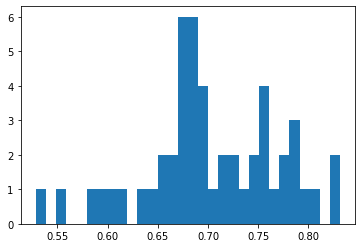

Val epoch 300, average corr 0.7019974337040206
Saving model...
Epoch: [301][10/270]	loss 24.116 (18.131)	image_p 0.121 (0.279)	gene_p 0.068 (0.269)
Epoch: [301][20/270]	loss 21.153 (17.841)	image_p 0.234 (0.295)	gene_p 0.167 (0.270)
Epoch: [301][30/270]	loss 16.652 (17.899)	image_p 0.373 (0.297)	gene_p 0.320 (0.272)
Epoch: [301][40/270]	loss 19.395 (17.528)	image_p 0.148 (0.294)	gene_p 0.287 (0.281)
Epoch: [301][50/270]	loss 11.389 (16.936)	image_p 0.418 (0.314)	gene_p 0.395 (0.294)
Epoch: [301][60/270]	loss 14.395 (16.716)	image_p 0.403 (0.324)	gene_p 0.403 (0.305)
Epoch: [301][70/270]	loss 19.454 (16.910)	image_p 0.192 (0.311)	gene_p 0.243 (0.301)
Epoch: [301][80/270]	loss 15.039 (16.685)	image_p 0.240 (0.312)	gene_p 0.354 (0.309)
Epoch: [301][90/270]	loss 18.505 (16.605)	image_p 0.235 (0.308)	gene_p 0.154 (0.310)
Epoch: [301][100/270]	loss 17.122 (16.637)	image_p 0.320 (0.308)	gene_p 0.369 (0.308)
Epoch: [301][110/270]	loss 17.563 (16.494)	image_p 0.157 (0.309)	gene_p 0.223 (0.315)


Epoch: [304][140/270]	loss 16.457 (14.896)	image_p 0.338 (0.346)	gene_p 0.269 (0.343)
Epoch: [304][150/270]	loss 12.154 (14.785)	image_p 0.411 (0.347)	gene_p 0.481 (0.348)
Epoch: [304][160/270]	loss 13.984 (14.658)	image_p 0.280 (0.348)	gene_p 0.426 (0.354)
Epoch: [304][170/270]	loss 11.825 (14.563)	image_p 0.449 (0.349)	gene_p 0.524 (0.363)
Epoch: [304][180/270]	loss 15.033 (14.490)	image_p 0.411 (0.350)	gene_p 0.313 (0.366)
Epoch: [304][190/270]	loss 13.563 (14.382)	image_p 0.422 (0.352)	gene_p 0.453 (0.373)
Epoch: [304][200/270]	loss 10.976 (14.315)	image_p 0.421 (0.354)	gene_p 0.427 (0.380)
Epoch: [304][210/270]	loss 15.512 (14.213)	image_p 0.385 (0.356)	gene_p 0.436 (0.386)
Epoch: [304][220/270]	loss 11.175 (14.116)	image_p 0.484 (0.360)	gene_p 0.556 (0.392)
Epoch: [304][230/270]	loss 10.295 (14.032)	image_p 0.471 (0.362)	gene_p 0.593 (0.398)
Epoch: [304][240/270]	loss 13.569 (13.908)	image_p 0.409 (0.367)	gene_p 0.548 (0.405)
Epoch: [304][250/270]	loss 9.679 (13.767)	image_p 0.44

Val epoch 307, average corr 0.6924296845208037
Epoch: [308][10/270]	loss 18.437 (17.478)	image_p 0.389 (0.342)	gene_p 0.242 (0.266)
Epoch: [308][20/270]	loss 16.163 (16.793)	image_p 0.492 (0.349)	gene_p 0.325 (0.294)
Epoch: [308][30/270]	loss 16.565 (16.669)	image_p 0.381 (0.343)	gene_p 0.294 (0.299)
Epoch: [308][40/270]	loss 15.701 (16.367)	image_p 0.368 (0.350)	gene_p 0.288 (0.301)
Epoch: [308][50/270]	loss 17.658 (16.220)	image_p 0.244 (0.354)	gene_p 0.268 (0.301)
Epoch: [308][60/270]	loss 11.895 (16.147)	image_p 0.517 (0.351)	gene_p 0.411 (0.301)
Epoch: [308][70/270]	loss 15.347 (16.108)	image_p 0.261 (0.349)	gene_p 0.401 (0.300)
Epoch: [308][80/270]	loss 12.735 (16.026)	image_p 0.371 (0.353)	gene_p 0.414 (0.304)
Epoch: [308][90/270]	loss 18.188 (15.975)	image_p 0.366 (0.356)	gene_p 0.382 (0.307)
Epoch: [308][100/270]	loss 15.222 (15.894)	image_p 0.347 (0.355)	gene_p 0.298 (0.308)
Epoch: [308][110/270]	loss 9.294 (15.683)	image_p 0.569 (0.360)	gene_p 0.568 (0.318)
Epoch: [308][120/

Epoch: [311][140/270]	loss 13.014 (15.585)	image_p 0.280 (0.361)	gene_p 0.339 (0.304)
Epoch: [311][150/270]	loss 12.203 (15.404)	image_p 0.538 (0.368)	gene_p 0.439 (0.313)
Epoch: [311][160/270]	loss 12.106 (15.227)	image_p 0.453 (0.375)	gene_p 0.273 (0.316)
Epoch: [311][170/270]	loss 15.030 (15.145)	image_p 0.510 (0.380)	gene_p 0.300 (0.320)
Epoch: [311][180/270]	loss 13.399 (15.011)	image_p 0.459 (0.384)	gene_p 0.369 (0.325)
Epoch: [311][190/270]	loss 7.954 (14.861)	image_p 0.590 (0.390)	gene_p 0.503 (0.329)
Epoch: [311][200/270]	loss 10.198 (14.740)	image_p 0.642 (0.394)	gene_p 0.552 (0.334)
Epoch: [311][210/270]	loss 7.101 (14.491)	image_p 0.565 (0.401)	gene_p 0.644 (0.342)
Epoch: [311][220/270]	loss 15.597 (14.325)	image_p 0.357 (0.407)	gene_p 0.359 (0.348)
Epoch: [311][230/270]	loss 10.411 (14.126)	image_p 0.647 (0.414)	gene_p 0.546 (0.356)
Epoch: [311][240/270]	loss 12.667 (13.952)	image_p 0.533 (0.421)	gene_p 0.422 (0.365)
Epoch: [311][250/270]	loss 7.862 (13.771)	image_p 0.638 

Val epoch 314, average corr 0.7061166994754038
Epoch: [315][10/270]	loss 19.047 (17.124)	image_p 0.280 (0.300)	gene_p 0.230 (0.306)
Epoch: [315][20/270]	loss 18.134 (16.714)	image_p 0.289 (0.304)	gene_p 0.331 (0.309)
Epoch: [315][30/270]	loss 19.975 (16.021)	image_p 0.248 (0.315)	gene_p 0.175 (0.319)
Epoch: [315][40/270]	loss 12.195 (15.831)	image_p 0.451 (0.331)	gene_p 0.501 (0.315)
Epoch: [315][50/270]	loss 12.741 (15.655)	image_p 0.304 (0.328)	gene_p 0.512 (0.329)
Epoch: [315][60/270]	loss 13.776 (15.656)	image_p 0.389 (0.325)	gene_p 0.393 (0.328)
Epoch: [315][70/270]	loss 17.012 (15.530)	image_p 0.298 (0.325)	gene_p 0.240 (0.334)
Epoch: [315][80/270]	loss 11.927 (15.372)	image_p 0.470 (0.331)	gene_p 0.564 (0.341)
Epoch: [315][90/270]	loss 15.624 (15.243)	image_p 0.301 (0.333)	gene_p 0.377 (0.347)
Epoch: [315][100/270]	loss 10.809 (15.088)	image_p 0.540 (0.339)	gene_p 0.446 (0.354)
Epoch: [315][110/270]	loss 14.318 (15.093)	image_p 0.230 (0.336)	gene_p 0.475 (0.354)
Epoch: [315][120

...

Val epoch 384, average corr 0.6820269615673987
Epoch: [385][10/270]	loss 13.471 (14.519)	image_p 0.358 (0.370)	gene_p 0.337 (0.364)
Epoch: [385][20/270]	loss 17.729 (14.733)	image_p 0.286 (0.370)	gene_p 0.294 (0.356)
Epoch: [385][30/270]	loss 13.930 (14.310)	image_p 0.414 (0.391)	gene_p 0.497 (0.377)
Epoch: [385][40/270]	loss 16.357 (14.210)	image_p 0.405 (0.391)	gene_p 0.329 (0.369)
Epoch: [385][50/270]	loss 12.187 (13.766)	image_p 0.466 (0.410)	gene_p 0.366 (0.376)
Epoch: [385][60/270]	loss 12.058 (13.538)	image_p 0.464 (0.410)	gene_p 0.283 (0.383)
Epoch: [385][70/270]	loss 9.749 (13.427)	image_p 0.533 (0.410)	gene_p 0.468 (0.384)
Epoch: [385][80/270]	loss 9.453 (13.085)	image_p 0.565 (0.419)	gene_p 0.574 (0.399)
Epoch: [385][90/270]	loss 9.760 (13.029)	image_p 0.481 (0.423)	gene_p 0.518 (0.401)
Epoch: [385][100/270]	loss 9.760 (12.987)	image_p 0.566 (0.425)	gene_p 0.562 (0.403)
Epoch: [385][110/270]	loss 17.018 (12.925)	image_p 0.377 (0.427)	gene_p 0.184 (0.403)
Epoch: [385][120/270

Epoch: [388][140/270]	loss 10.275 (13.154)	image_p 0.512 (0.440)	gene_p 0.535 (0.381)
Epoch: [388][150/270]	loss 7.529 (12.975)	image_p 0.575 (0.445)	gene_p 0.533 (0.387)
Epoch: [388][160/270]	loss 10.207 (12.748)	image_p 0.569 (0.452)	gene_p 0.355 (0.394)
Epoch: [388][170/270]	loss 10.622 (12.595)	image_p 0.475 (0.458)	gene_p 0.601 (0.401)
Epoch: [388][180/270]	loss 12.638 (12.432)	image_p 0.377 (0.460)	gene_p 0.529 (0.409)
Epoch: [388][190/270]	loss 11.028 (12.205)	image_p 0.509 (0.468)	gene_p 0.427 (0.419)
Epoch: [388][200/270]	loss 6.919 (12.030)	image_p 0.721 (0.474)	gene_p 0.655 (0.427)
Epoch: [388][210/270]	loss 6.567 (11.810)	image_p 0.660 (0.480)	gene_p 0.704 (0.437)
Epoch: [388][220/270]	loss 9.621 (11.624)	image_p 0.667 (0.486)	gene_p 0.285 (0.443)
Epoch: [388][230/270]	loss 4.295 (11.415)	image_p 0.698 (0.492)	gene_p 0.849 (0.452)
Epoch: [388][240/270]	loss 2.634 (11.153)	image_p 0.791 (0.503)	gene_p 0.948 (0.464)
Epoch: [388][250/270]	loss 7.965 (10.928)	image_p 0.683 (0.5

Val epoch 391, average corr 0.697207014542344
Epoch: [392][10/270]	loss 14.157 (14.187)	image_p 0.274 (0.351)	gene_p 0.352 (0.379)
Epoch: [392][20/270]	loss 13.009 (14.510)	image_p 0.461 (0.351)	gene_p 0.420 (0.370)
Epoch: [392][30/270]	loss 12.309 (13.963)	image_p 0.368 (0.385)	gene_p 0.451 (0.378)
Epoch: [392][40/270]	loss 20.472 (14.122)	image_p 0.308 (0.382)	gene_p 0.206 (0.381)
Epoch: [392][50/270]	loss 14.622 (13.827)	image_p 0.376 (0.389)	gene_p 0.423 (0.386)
Epoch: [392][60/270]	loss 11.584 (13.626)	image_p 0.474 (0.398)	gene_p 0.470 (0.394)
Epoch: [392][70/270]	loss 13.861 (13.501)	image_p 0.418 (0.406)	gene_p 0.313 (0.398)
Epoch: [392][80/270]	loss 13.781 (13.414)	image_p 0.342 (0.408)	gene_p 0.307 (0.399)
Epoch: [392][90/270]	loss 15.728 (13.328)	image_p 0.271 (0.412)	gene_p 0.295 (0.397)
Epoch: [392][100/270]	loss 12.071 (13.192)	image_p 0.578 (0.416)	gene_p 0.299 (0.400)
Epoch: [392][110/270]	loss 13.622 (13.124)	image_p 0.431 (0.414)	gene_p 0.381 (0.404)
Epoch: [392][120/

Epoch: [395][140/270]	loss 13.791 (13.144)	image_p 0.485 (0.402)	gene_p 0.296 (0.401)
Epoch: [395][150/270]	loss 13.680 (13.037)	image_p 0.439 (0.407)	gene_p 0.334 (0.402)
Epoch: [395][160/270]	loss 12.343 (12.927)	image_p 0.355 (0.412)	gene_p 0.420 (0.406)
Epoch: [395][170/270]	loss 10.786 (12.869)	image_p 0.516 (0.415)	gene_p 0.464 (0.408)
Epoch: [395][180/270]	loss 9.460 (12.754)	image_p 0.565 (0.417)	gene_p 0.486 (0.415)
Epoch: [395][190/270]	loss 9.956 (12.688)	image_p 0.547 (0.421)	gene_p 0.566 (0.416)
Epoch: [395][200/270]	loss 7.473 (12.549)	image_p 0.687 (0.426)	gene_p 0.511 (0.421)
Epoch: [395][210/270]	loss 9.428 (12.347)	image_p 0.487 (0.436)	gene_p 0.575 (0.429)
Epoch: [395][220/270]	loss 7.327 (12.150)	image_p 0.718 (0.443)	gene_p 0.528 (0.436)
Epoch: [395][230/270]	loss 4.826 (11.984)	image_p 0.799 (0.449)	gene_p 0.685 (0.443)
Epoch: [395][240/270]	loss 5.680 (11.752)	image_p 0.672 (0.456)	gene_p 0.855 (0.454)
Epoch: [395][250/270]	loss 10.832 (11.553)	image_p 0.565 (0.4

Val epoch 398, average corr 0.6160123470786483
Epoch: [399][10/270]	loss 16.598 (14.024)	image_p 0.315 (0.380)	gene_p 0.173 (0.361)
Epoch: [399][20/270]	loss 12.935 (13.661)	image_p 0.272 (0.392)	gene_p 0.505 (0.369)
Epoch: [399][30/270]	loss 11.670 (13.532)	image_p 0.450 (0.389)	gene_p 0.437 (0.388)
Epoch: [399][40/270]	loss 12.326 (13.220)	image_p 0.357 (0.390)	gene_p 0.514 (0.411)
Epoch: [399][50/270]	loss 10.936 (12.886)	image_p 0.466 (0.402)	gene_p 0.482 (0.422)
Epoch: [399][60/270]	loss 10.598 (12.628)	image_p 0.411 (0.414)	gene_p 0.521 (0.429)
Epoch: [399][70/270]	loss 12.498 (12.614)	image_p 0.395 (0.420)	gene_p 0.513 (0.426)
Epoch: [399][80/270]	loss 7.776 (12.460)	image_p 0.578 (0.425)	gene_p 0.655 (0.432)
Epoch: [399][90/270]	loss 14.231 (12.364)	image_p 0.317 (0.432)	gene_p 0.385 (0.431)
Epoch: [399][100/270]	loss 13.751 (12.451)	image_p 0.355 (0.434)	gene_p 0.602 (0.428)
Epoch: [399][110/270]	loss 11.190 (12.302)	image_p 0.502 (0.441)	gene_p 0.407 (0.431)
Epoch: [399][120/

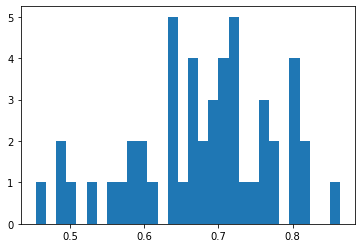

Val epoch 400, average corr 0.677846742497122
Saving model...
Epoch: [401][10/270]	loss 13.999 (12.637)	image_p 0.433 (0.430)	gene_p 0.281 (0.421)
Epoch: [401][20/270]	loss 14.989 (12.528)	image_p 0.422 (0.422)	gene_p 0.352 (0.438)
Epoch: [401][30/270]	loss 11.972 (12.405)	image_p 0.422 (0.423)	gene_p 0.440 (0.433)
Epoch: [401][40/270]	loss 14.645 (12.340)	image_p 0.464 (0.431)	gene_p 0.310 (0.434)
Epoch: [401][50/270]	loss 11.592 (12.054)	image_p 0.297 (0.442)	gene_p 0.495 (0.447)
Epoch: [401][60/270]	loss 9.429 (12.005)	image_p 0.571 (0.443)	gene_p 0.448 (0.444)
Epoch: [401][70/270]	loss 15.379 (11.995)	image_p 0.392 (0.444)	gene_p 0.341 (0.444)
Epoch: [401][80/270]	loss 14.583 (12.068)	image_p 0.388 (0.443)	gene_p 0.317 (0.439)
Epoch: [401][90/270]	loss 13.682 (11.906)	image_p 0.485 (0.449)	gene_p 0.372 (0.444)
Epoch: [401][100/270]	loss 9.352 (11.822)	image_p 0.401 (0.453)	gene_p 0.497 (0.445)
Epoch: [401][110/270]	loss 13.013 (11.861)	image_p 0.456 (0.451)	gene_p 0.480 (0.445)
Epo

Epoch: [404][140/270]	loss 8.488 (12.011)	image_p 0.578 (0.444)	gene_p 0.591 (0.440)
Epoch: [404][150/270]	loss 10.514 (11.933)	image_p 0.515 (0.450)	gene_p 0.551 (0.442)
Epoch: [404][160/270]	loss 11.391 (11.817)	image_p 0.477 (0.459)	gene_p 0.501 (0.443)
Epoch: [404][170/270]	loss 9.662 (11.754)	image_p 0.488 (0.463)	gene_p 0.652 (0.445)
Epoch: [404][180/270]	loss 10.958 (11.681)	image_p 0.464 (0.467)	gene_p 0.427 (0.447)
Epoch: [404][190/270]	loss 8.800 (11.557)	image_p 0.439 (0.473)	gene_p 0.596 (0.452)
Epoch: [404][200/270]	loss 7.702 (11.451)	image_p 0.632 (0.479)	gene_p 0.578 (0.455)
Epoch: [404][210/270]	loss 9.352 (11.385)	image_p 0.570 (0.482)	gene_p 0.493 (0.460)
Epoch: [404][220/270]	loss 6.536 (11.253)	image_p 0.732 (0.488)	gene_p 0.658 (0.467)
Epoch: [404][230/270]	loss 7.341 (11.114)	image_p 0.634 (0.495)	gene_p 0.593 (0.470)
Epoch: [404][240/270]	loss 6.909 (10.972)	image_p 0.675 (0.502)	gene_p 0.633 (0.475)
Epoch: [404][250/270]	loss 5.536 (10.783)	image_p 0.714 (0.512

Val epoch 407, average corr 0.7130687849773776
Epoch: [408][10/270]	loss 15.179 (15.197)	image_p 0.283 (0.318)	gene_p 0.379 (0.344)
Epoch: [408][20/270]	loss 11.390 (14.083)	image_p 0.439 (0.351)	gene_p 0.376 (0.368)
Epoch: [408][30/270]	loss 13.066 (13.584)	image_p 0.360 (0.373)	gene_p 0.355 (0.381)
Epoch: [408][40/270]	loss 13.145 (13.354)	image_p 0.518 (0.397)	gene_p 0.365 (0.373)
Epoch: [408][50/270]	loss 12.181 (13.041)	image_p 0.525 (0.414)	gene_p 0.473 (0.386)
Epoch: [408][60/270]	loss 12.263 (12.865)	image_p 0.341 (0.420)	gene_p 0.459 (0.389)
Epoch: [408][70/270]	loss 15.118 (12.763)	image_p 0.339 (0.417)	gene_p 0.314 (0.397)
Epoch: [408][80/270]	loss 12.507 (12.744)	image_p 0.458 (0.422)	gene_p 0.490 (0.395)
Epoch: [408][90/270]	loss 14.254 (12.609)	image_p 0.317 (0.426)	gene_p 0.446 (0.399)
Epoch: [408][100/270]	loss 11.427 (12.422)	image_p 0.343 (0.432)	gene_p 0.468 (0.405)
Epoch: [408][110/270]	loss 12.078 (12.466)	image_p 0.328 (0.434)	gene_p 0.425 (0.406)
Epoch: [408][120

Epoch: [411][140/270]	loss 11.030 (12.427)	image_p 0.574 (0.449)	gene_p 0.427 (0.397)
Epoch: [411][150/270]	loss 9.552 (12.329)	image_p 0.477 (0.449)	gene_p 0.584 (0.401)
Epoch: [411][160/270]	loss 9.020 (12.195)	image_p 0.603 (0.457)	gene_p 0.603 (0.404)
Epoch: [411][170/270]	loss 9.418 (12.053)	image_p 0.546 (0.466)	gene_p 0.517 (0.407)
Epoch: [411][180/270]	loss 9.084 (11.877)	image_p 0.592 (0.473)	gene_p 0.393 (0.411)
Epoch: [411][190/270]	loss 7.231 (11.695)	image_p 0.723 (0.481)	gene_p 0.469 (0.418)
Epoch: [411][200/270]	loss 6.678 (11.506)	image_p 0.638 (0.487)	gene_p 0.638 (0.425)
Epoch: [411][210/270]	loss 7.027 (11.308)	image_p 0.582 (0.496)	gene_p 0.647 (0.434)
Epoch: [411][220/270]	loss 8.553 (11.109)	image_p 0.490 (0.503)	gene_p 0.687 (0.443)
Epoch: [411][230/270]	loss 4.807 (10.906)	image_p 0.721 (0.511)	gene_p 0.801 (0.453)
Epoch: [411][240/270]	loss 4.688 (10.677)	image_p 0.696 (0.519)	gene_p 0.791 (0.463)
Epoch: [411][250/270]	loss 4.601 (10.427)	image_p 0.756 (0.528)	

Val epoch 414, average corr 0.7006459542189287
Epoch: [415][10/270]	loss 13.654 (13.385)	image_p 0.414 (0.393)	gene_p 0.472 (0.415)
Epoch: [415][20/270]	loss 14.363 (13.243)	image_p 0.491 (0.408)	gene_p 0.332 (0.423)
Epoch: [415][30/270]	loss 10.585 (12.841)	image_p 0.406 (0.413)	gene_p 0.497 (0.433)
Epoch: [415][40/270]	loss 11.070 (12.849)	image_p 0.264 (0.411)	gene_p 0.610 (0.421)
Epoch: [415][50/270]	loss 12.502 (12.490)	image_p 0.503 (0.432)	gene_p 0.330 (0.420)
Epoch: [415][60/270]	loss 10.886 (12.247)	image_p 0.549 (0.443)	gene_p 0.379 (0.427)
Epoch: [415][70/270]	loss 12.606 (12.044)	image_p 0.320 (0.447)	gene_p 0.476 (0.440)
Epoch: [415][80/270]	loss 11.445 (11.887)	image_p 0.496 (0.453)	gene_p 0.413 (0.445)
Epoch: [415][90/270]	loss 11.358 (11.809)	image_p 0.422 (0.456)	gene_p 0.451 (0.445)
Epoch: [415][100/270]	loss 8.801 (11.710)	image_p 0.699 (0.461)	gene_p 0.455 (0.448)
Epoch: [415][110/270]	loss 11.934 (11.681)	image_p 0.497 (0.461)	gene_p 0.428 (0.449)
Epoch: [415][120/

...

Epoch: [485][110/270]	loss 6.274 (9.418)	image_p 0.619 (0.569)	gene_p 0.655 (0.522)
Epoch: [485][120/270]	loss 7.360 (9.326)	image_p 0.674 (0.570)	gene_p 0.463 (0.524)
Epoch: [485][130/270]	loss 7.024 (9.186)	image_p 0.708 (0.577)	gene_p 0.522 (0.531)
Epoch: [485][140/270]	loss 8.839 (9.099)	image_p 0.684 (0.581)	gene_p 0.555 (0.534)
Epoch: [485][150/270]	loss 5.775 (8.990)	image_p 0.609 (0.586)	gene_p 0.721 (0.539)
Epoch: [485][160/270]	loss 5.630 (8.899)	image_p 0.679 (0.592)	gene_p 0.764 (0.541)
Epoch: [485][170/270]	loss 7.333 (8.787)	image_p 0.698 (0.598)	gene_p 0.591 (0.545)
Epoch: [485][180/270]	loss 5.646 (8.648)	image_p 0.788 (0.603)	gene_p 0.577 (0.550)
Epoch: [485][190/270]	loss 4.966 (8.520)	image_p 0.676 (0.611)	gene_p 0.786 (0.556)
Epoch: [485][200/270]	loss 4.807 (8.362)	image_p 0.779 (0.617)	gene_p 0.663 (0.564)
Epoch: [485][210/270]	loss 3.713 (8.199)	image_p 0.856 (0.625)	gene_p 0.778 (0.569)
Epoch: [485][220/270]	loss 2.905 (8.039)	image_p 0.754 (0.630)	gene_p 0.908 

Epoch: [488][260/270]	loss 7.738 (9.492)	image_p 0.660 (0.576)	gene_p 0.626 (0.527)
Epoch: [488][270/270]	loss 5.608 (9.377)	image_p 0.740 (0.579)	gene_p 0.709 (0.533)
Val epoch 488, average corr 0.7355396951364054
Epoch: [489][10/270]	loss 8.808 (10.199)	image_p 0.593 (0.549)	gene_p 0.574 (0.486)
Epoch: [489][20/270]	loss 11.974 (9.871)	image_p 0.334 (0.541)	gene_p 0.477 (0.499)
Epoch: [489][30/270]	loss 7.345 (9.851)	image_p 0.655 (0.560)	gene_p 0.590 (0.502)
Epoch: [489][40/270]	loss 8.158 (9.716)	image_p 0.596 (0.567)	gene_p 0.535 (0.508)
Epoch: [489][50/270]	loss 10.667 (9.441)	image_p 0.571 (0.575)	gene_p 0.490 (0.520)
Epoch: [489][60/270]	loss 8.523 (9.107)	image_p 0.528 (0.585)	gene_p 0.580 (0.532)
Epoch: [489][70/270]	loss 8.078 (9.018)	image_p 0.641 (0.588)	gene_p 0.619 (0.537)
Epoch: [489][80/270]	loss 10.352 (8.962)	image_p 0.462 (0.585)	gene_p 0.537 (0.543)
Epoch: [489][90/270]	loss 10.131 (8.867)	image_p 0.505 (0.587)	gene_p 0.410 (0.549)
Epoch: [489][100/270]	loss 8.001 

Epoch: [492][130/270]	loss 9.628 (9.663)	image_p 0.596 (0.550)	gene_p 0.418 (0.514)
Epoch: [492][140/270]	loss 7.646 (9.619)	image_p 0.628 (0.553)	gene_p 0.582 (0.518)
Epoch: [492][150/270]	loss 10.109 (9.574)	image_p 0.534 (0.553)	gene_p 0.501 (0.523)
Epoch: [492][160/270]	loss 12.056 (9.545)	image_p 0.446 (0.554)	gene_p 0.441 (0.523)
Epoch: [492][170/270]	loss 7.496 (9.454)	image_p 0.650 (0.557)	gene_p 0.574 (0.527)
Epoch: [492][180/270]	loss 9.507 (9.402)	image_p 0.436 (0.558)	gene_p 0.667 (0.532)
Epoch: [492][190/270]	loss 9.528 (9.348)	image_p 0.520 (0.559)	gene_p 0.492 (0.535)
Epoch: [492][200/270]	loss 8.150 (9.359)	image_p 0.695 (0.560)	gene_p 0.552 (0.537)
Epoch: [492][210/270]	loss 7.714 (9.279)	image_p 0.596 (0.563)	gene_p 0.688 (0.540)
Epoch: [492][220/270]	loss 5.430 (9.177)	image_p 0.734 (0.568)	gene_p 0.779 (0.546)
Epoch: [492][230/270]	loss 12.463 (9.112)	image_p 0.632 (0.571)	gene_p 0.527 (0.549)
Epoch: [492][240/270]	loss 5.503 (9.019)	image_p 0.708 (0.574)	gene_p 0.6

Val epoch 495, average corr 0.7367657971492472
Epoch: [496][10/270]	loss 11.053 (10.727)	image_p 0.486 (0.473)	gene_p 0.516 (0.516)
Epoch: [496][20/270]	loss 11.469 (10.405)	image_p 0.545 (0.506)	gene_p 0.477 (0.517)
Epoch: [496][30/270]	loss 9.681 (10.321)	image_p 0.450 (0.500)	gene_p 0.552 (0.510)
Epoch: [496][40/270]	loss 10.917 (10.039)	image_p 0.533 (0.522)	gene_p 0.475 (0.512)
Epoch: [496][50/270]	loss 6.372 (9.611)	image_p 0.681 (0.539)	gene_p 0.644 (0.528)
Epoch: [496][60/270]	loss 7.610 (9.482)	image_p 0.597 (0.543)	gene_p 0.643 (0.530)
Epoch: [496][70/270]	loss 10.723 (9.388)	image_p 0.532 (0.549)	gene_p 0.525 (0.537)
Epoch: [496][80/270]	loss 8.305 (9.375)	image_p 0.533 (0.552)	gene_p 0.712 (0.538)
Epoch: [496][90/270]	loss 8.322 (9.203)	image_p 0.660 (0.563)	gene_p 0.438 (0.542)
Epoch: [496][100/270]	loss 9.387 (9.087)	image_p 0.616 (0.569)	gene_p 0.548 (0.545)
Epoch: [496][110/270]	loss 6.895 (9.026)	image_p 0.733 (0.575)	gene_p 0.612 (0.548)
Epoch: [496][120/270]	loss 8.9

Epoch: [499][160/270]	loss 7.135 (9.814)	image_p 0.729 (0.586)	gene_p 0.653 (0.490)
Epoch: [499][170/270]	loss 10.509 (9.725)	image_p 0.645 (0.592)	gene_p 0.442 (0.494)
Epoch: [499][180/270]	loss 10.122 (9.640)	image_p 0.554 (0.595)	gene_p 0.477 (0.496)
Epoch: [499][190/270]	loss 7.157 (9.554)	image_p 0.696 (0.602)	gene_p 0.652 (0.499)
Epoch: [499][200/270]	loss 4.279 (9.471)	image_p 0.695 (0.605)	gene_p 0.842 (0.504)
Epoch: [499][210/270]	loss 6.898 (9.334)	image_p 0.708 (0.611)	gene_p 0.502 (0.509)
Epoch: [499][220/270]	loss 6.126 (9.231)	image_p 0.633 (0.616)	gene_p 0.660 (0.513)
Epoch: [499][230/270]	loss 5.004 (9.096)	image_p 0.789 (0.621)	gene_p 0.721 (0.519)
Epoch: [499][240/270]	loss 8.315 (8.969)	image_p 0.736 (0.628)	gene_p 0.468 (0.525)
Epoch: [499][250/270]	loss 7.593 (8.837)	image_p 0.745 (0.634)	gene_p 0.578 (0.530)
Epoch: [499][260/270]	loss 1.345 (8.629)	image_p 0.971 (0.643)	gene_p 0.928 (0.540)
Epoch: [499][270/270]	loss 2.040 (8.449)	image_p 0.993 (0.651)	gene_p 0.75

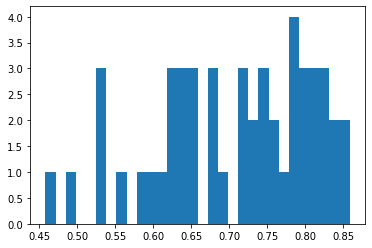

Val epoch 500, average corr 0.7064886062642357
Saving model...
Epoch: [501][10/270]	loss 9.476 (10.023)	image_p 0.547 (0.499)	gene_p 0.638 (0.513)
Epoch: [501][20/270]	loss 9.785 (9.855)	image_p 0.544 (0.525)	gene_p 0.551 (0.520)
Epoch: [501][30/270]	loss 10.283 (9.667)	image_p 0.557 (0.548)	gene_p 0.525 (0.527)
Epoch: [501][40/270]	loss 11.433 (9.572)	image_p 0.538 (0.551)	gene_p 0.461 (0.526)
Epoch: [501][50/270]	loss 8.183 (9.454)	image_p 0.687 (0.550)	gene_p 0.429 (0.532)
Epoch: [501][60/270]	loss 8.242 (9.212)	image_p 0.709 (0.559)	gene_p 0.533 (0.539)
Epoch: [501][70/270]	loss 8.140 (9.204)	image_p 0.560 (0.567)	gene_p 0.504 (0.538)
Epoch: [501][80/270]	loss 9.468 (9.144)	image_p 0.626 (0.567)	gene_p 0.419 (0.542)
Epoch: [501][90/270]	loss 11.002 (9.039)	image_p 0.393 (0.572)	gene_p 0.634 (0.547)
Epoch: [501][100/270]	loss 8.317 (9.018)	image_p 0.652 (0.570)	gene_p 0.539 (0.546)
Epoch: [501][110/270]	loss 9.981 (8.951)	image_p 0.491 (0.572)	gene_p 0.628 (0.553)
Epoch: [501][120/2

Epoch: [504][160/270]	loss 5.408 (8.753)	image_p 0.700 (0.598)	gene_p 0.715 (0.554)
Epoch: [504][170/270]	loss 6.467 (8.670)	image_p 0.641 (0.602)	gene_p 0.725 (0.559)
Epoch: [504][180/270]	loss 6.494 (8.553)	image_p 0.632 (0.606)	gene_p 0.676 (0.565)
Epoch: [504][190/270]	loss 8.681 (8.479)	image_p 0.760 (0.611)	gene_p 0.503 (0.567)
Epoch: [504][200/270]	loss 2.982 (8.392)	image_p 0.837 (0.614)	gene_p 0.838 (0.571)
Epoch: [504][210/270]	loss 7.158 (8.295)	image_p 0.699 (0.619)	gene_p 0.666 (0.575)
Epoch: [504][220/270]	loss 6.418 (8.185)	image_p 0.758 (0.625)	gene_p 0.605 (0.579)
Epoch: [504][230/270]	loss 6.424 (8.075)	image_p 0.831 (0.629)	gene_p 0.707 (0.583)
Epoch: [504][240/270]	loss 4.070 (7.987)	image_p 0.814 (0.634)	gene_p 0.748 (0.588)
Epoch: [504][250/270]	loss 3.544 (7.900)	image_p 0.805 (0.640)	gene_p 0.795 (0.590)
Epoch: [504][260/270]	loss 3.304 (7.769)	image_p 0.918 (0.647)	gene_p 0.701 (0.595)
Epoch: [504][270/270]	loss 6.168 (7.642)	image_p 0.836 (0.654)	gene_p 0.622 

Epoch: [508][40/270]	loss 8.539 (10.368)	image_p 0.695 (0.562)	gene_p 0.599 (0.481)
Epoch: [508][50/270]	loss 9.222 (10.277)	image_p 0.538 (0.557)	gene_p 0.453 (0.478)
Epoch: [508][60/270]	loss 6.856 (10.106)	image_p 0.760 (0.561)	gene_p 0.527 (0.487)
Epoch: [508][70/270]	loss 10.699 (9.951)	image_p 0.518 (0.567)	gene_p 0.438 (0.493)
Epoch: [508][80/270]	loss 11.436 (9.866)	image_p 0.458 (0.562)	gene_p 0.326 (0.494)
Epoch: [508][90/270]	loss 10.627 (9.745)	image_p 0.383 (0.570)	gene_p 0.496 (0.494)
Epoch: [508][100/270]	loss 7.795 (9.696)	image_p 0.803 (0.568)	gene_p 0.502 (0.497)
Epoch: [508][110/270]	loss 8.948 (9.618)	image_p 0.558 (0.565)	gene_p 0.528 (0.504)
Epoch: [508][120/270]	loss 10.141 (9.539)	image_p 0.589 (0.567)	gene_p 0.498 (0.511)
Epoch: [508][130/270]	loss 9.701 (9.409)	image_p 0.515 (0.571)	gene_p 0.501 (0.518)
Epoch: [508][140/270]	loss 10.302 (9.346)	image_p 0.601 (0.571)	gene_p 0.472 (0.521)
Epoch: [508][150/270]	loss 6.359 (9.226)	image_p 0.721 (0.577)	gene_p 0.66

Epoch: [511][190/270]	loss 8.262 (9.026)	image_p 0.658 (0.578)	gene_p 0.552 (0.551)
Epoch: [511][200/270]	loss 6.861 (8.957)	image_p 0.746 (0.582)	gene_p 0.529 (0.553)
Epoch: [511][210/270]	loss 7.690 (8.885)	image_p 0.698 (0.585)	gene_p 0.529 (0.555)
Epoch: [511][220/270]	loss 8.312 (8.823)	image_p 0.626 (0.587)	gene_p 0.555 (0.559)
Epoch: [511][230/270]	loss 6.006 (8.759)	image_p 0.637 (0.589)	gene_p 0.736 (0.563)
Epoch: [511][240/270]	loss 4.718 (8.693)	image_p 0.755 (0.595)	gene_p 0.737 (0.566)
Epoch: [511][250/270]	loss 6.822 (8.595)	image_p 0.734 (0.600)	gene_p 0.609 (0.570)
Epoch: [511][260/270]	loss 6.651 (8.492)	image_p 0.646 (0.607)	gene_p 0.685 (0.574)
Epoch: [511][270/270]	loss 5.341 (8.419)	image_p 1.000 (0.611)	gene_p 0.627 (0.577)
Val epoch 511, average corr 0.7397548105166604
Epoch: [512][10/270]	loss 10.964 (10.331)	image_p 0.380 (0.508)	gene_p 0.545 (0.536)
Epoch: [512][20/270]	loss 9.861 (10.328)	image_p 0.641 (0.518)	gene_p 0.516 (0.509)
Epoch: [512][30/270]	loss 11

Epoch: [515][70/270]	loss 8.556 (10.824)	image_p 0.588 (0.495)	gene_p 0.565 (0.488)
Epoch: [515][80/270]	loss 6.669 (10.623)	image_p 0.599 (0.498)	gene_p 0.804 (0.498)
Epoch: [515][90/270]	loss 9.255 (10.411)	image_p 0.545 (0.506)	gene_p 0.508 (0.502)
Epoch: [515][100/270]	loss 5.114 (10.150)	image_p 0.760 (0.518)	gene_p 0.705 (0.513)
Epoch: [515][110/270]	loss 9.198 (10.101)	image_p 0.617 (0.523)	gene_p 0.431 (0.507)
Epoch: [515][120/270]	loss 10.494 (10.088)	image_p 0.546 (0.526)	gene_p 0.417 (0.504)
Epoch: [515][130/270]	loss 9.507 (10.092)	image_p 0.548 (0.529)	gene_p 0.465 (0.502)
Epoch: [515][140/270]	loss 11.834 (10.067)	image_p 0.521 (0.533)	gene_p 0.230 (0.497)
Epoch: [515][150/270]	loss 13.173 (10.007)	image_p 0.532 (0.535)	gene_p 0.322 (0.499)
Epoch: [515][160/270]	loss 10.457 (9.969)	image_p 0.516 (0.540)	gene_p 0.335 (0.495)
Epoch: [515][170/270]	loss 9.668 (9.939)	image_p 0.671 (0.546)	gene_p 0.370 (0.494)
Epoch: [515][180/270]	loss 7.529 (9.907)	image_p 0.613 (0.550)	gen

...

Epoch: [554][90/270]	loss 6.712 (9.023)	image_p 0.650 (0.577)	gene_p 0.644 (0.545)
Epoch: [554][100/270]	loss 4.491 (8.862)	image_p 0.854 (0.584)	gene_p 0.705 (0.552)
Epoch: [554][110/270]	loss 10.352 (8.786)	image_p 0.487 (0.586)	gene_p 0.573 (0.559)
Epoch: [554][120/270]	loss 7.413 (8.685)	image_p 0.742 (0.593)	gene_p 0.457 (0.561)
Epoch: [554][130/270]	loss 5.998 (8.591)	image_p 0.824 (0.599)	gene_p 0.650 (0.565)
Epoch: [554][140/270]	loss 4.869 (8.386)	image_p 0.743 (0.605)	gene_p 0.690 (0.574)
Epoch: [554][150/270]	loss 7.625 (8.313)	image_p 0.586 (0.607)	gene_p 0.583 (0.578)
Epoch: [554][160/270]	loss 6.995 (8.162)	image_p 0.638 (0.612)	gene_p 0.607 (0.584)
Epoch: [554][170/270]	loss 7.937 (8.052)	image_p 0.653 (0.617)	gene_p 0.688 (0.589)
Epoch: [554][180/270]	loss 6.275 (7.957)	image_p 0.706 (0.621)	gene_p 0.576 (0.594)
Epoch: [554][190/270]	loss 3.777 (7.830)	image_p 0.792 (0.627)	gene_p 0.735 (0.600)
Epoch: [554][200/270]	loss 7.460 (7.728)	image_p 0.765 (0.631)	gene_p 0.414 

Epoch: [557][250/270]	loss 2.679 (6.946)	image_p 0.886 (0.681)	gene_p 0.849 (0.631)
Epoch: [557][260/270]	loss 2.009 (6.790)	image_p 0.884 (0.687)	gene_p 0.924 (0.640)
Epoch: [557][270/270]	loss 2.687 (6.626)	image_p 0.979 (0.694)	gene_p 0.779 (0.649)
Val epoch 557, average corr 0.738616158388902
Epoch: [558][10/270]	loss 11.796 (11.265)	image_p 0.559 (0.513)	gene_p 0.391 (0.415)
Epoch: [558][20/270]	loss 9.992 (10.368)	image_p 0.494 (0.532)	gene_p 0.542 (0.470)
Epoch: [558][30/270]	loss 9.001 (9.909)	image_p 0.559 (0.534)	gene_p 0.632 (0.504)
Epoch: [558][40/270]	loss 6.358 (9.644)	image_p 0.705 (0.545)	gene_p 0.659 (0.520)
Epoch: [558][50/270]	loss 6.741 (9.312)	image_p 0.585 (0.558)	gene_p 0.744 (0.533)
Epoch: [558][60/270]	loss 7.675 (9.114)	image_p 0.515 (0.567)	gene_p 0.626 (0.538)
Epoch: [558][70/270]	loss 10.108 (9.067)	image_p 0.538 (0.564)	gene_p 0.587 (0.545)
Epoch: [558][80/270]	loss 9.950 (8.911)	image_p 0.581 (0.574)	gene_p 0.502 (0.550)
Epoch: [558][90/270]	loss 10.960 (

Epoch: [561][130/270]	loss 9.702 (8.849)	image_p 0.608 (0.586)	gene_p 0.461 (0.558)
Epoch: [561][140/270]	loss 5.480 (8.753)	image_p 0.729 (0.589)	gene_p 0.610 (0.562)
Epoch: [561][150/270]	loss 7.818 (8.764)	image_p 0.531 (0.589)	gene_p 0.571 (0.559)
Epoch: [561][160/270]	loss 10.928 (8.696)	image_p 0.391 (0.590)	gene_p 0.499 (0.560)
Epoch: [561][170/270]	loss 9.618 (8.627)	image_p 0.623 (0.594)	gene_p 0.504 (0.563)
Epoch: [561][180/270]	loss 7.056 (8.552)	image_p 0.744 (0.598)	gene_p 0.579 (0.565)
Epoch: [561][190/270]	loss 7.691 (8.514)	image_p 0.673 (0.600)	gene_p 0.559 (0.567)
Epoch: [561][200/270]	loss 9.895 (8.460)	image_p 0.614 (0.603)	gene_p 0.408 (0.570)
Epoch: [561][210/270]	loss 6.121 (8.385)	image_p 0.631 (0.607)	gene_p 0.765 (0.573)
Epoch: [561][220/270]	loss 3.451 (8.252)	image_p 0.796 (0.612)	gene_p 0.901 (0.580)
Epoch: [561][230/270]	loss 6.645 (8.216)	image_p 0.825 (0.616)	gene_p 0.534 (0.582)
Epoch: [561][240/270]	loss 5.561 (8.138)	image_p 0.767 (0.620)	gene_p 0.674

Epoch: [565][10/270]	loss 10.568 (9.941)	image_p 0.616 (0.516)	gene_p 0.312 (0.504)
Epoch: [565][20/270]	loss 12.544 (9.767)	image_p 0.454 (0.550)	gene_p 0.398 (0.514)
Epoch: [565][30/270]	loss 6.519 (9.402)	image_p 0.763 (0.557)	gene_p 0.578 (0.536)
Epoch: [565][40/270]	loss 4.707 (8.964)	image_p 0.670 (0.571)	gene_p 0.710 (0.559)
Epoch: [565][50/270]	loss 7.105 (8.665)	image_p 0.714 (0.588)	gene_p 0.590 (0.566)
Epoch: [565][60/270]	loss 9.369 (8.558)	image_p 0.466 (0.595)	gene_p 0.508 (0.566)
Epoch: [565][70/270]	loss 9.011 (8.446)	image_p 0.519 (0.595)	gene_p 0.425 (0.570)
Epoch: [565][80/270]	loss 8.288 (8.353)	image_p 0.467 (0.595)	gene_p 0.593 (0.576)
Epoch: [565][90/270]	loss 8.938 (8.278)	image_p 0.653 (0.602)	gene_p 0.510 (0.574)
Epoch: [565][100/270]	loss 7.323 (8.218)	image_p 0.603 (0.602)	gene_p 0.511 (0.575)
Epoch: [565][110/270]	loss 8.199 (8.178)	image_p 0.578 (0.604)	gene_p 0.516 (0.579)
Epoch: [565][120/270]	loss 5.301 (8.119)	image_p 0.697 (0.603)	gene_p 0.683 (0.585)

RuntimeError: DataLoader worker (pid 114220) is killed by signal: Killed. 

In [80]:
hist = dict()
hist['loss'] = []
hist['corr_val'] = []
hist['image_loss'] = []
hist['image_prob'] = []
hist['gene_loss'] = []
hist['gene_prob'] = []

save_freq = 10
best_corr = -float("inf")

for epoch in range(1000):
    loss, image_loss, image_prob, gene_loss, gene_prob = \
        train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    hist['loss'].append(loss)
    hist['image_loss'].append(image_loss)
    hist['image_prob'].append(image_prob)
    hist['gene_loss'].append(gene_loss)
    hist['gene_prob'].append(gene_prob)
    
    corr = test(epoch, test_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    hist['corr_val'].append(corr)
    # Check if this is the best corr so far
    if corr > best_corr:
        best_corr = corr
        hist_best = {
            'model': model.state_dict(),
            'contrast': contrast.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch,
            'corr_val': corr
        }
        torch.save(hist_best, os.path.join(model_dir, "epoch_best.pt"))
        
    # Save model
    if epoch % save_freq == 0 and epoch != 0:
        print("Saving model...")
        state = { 'model': model.state_dict(),
                  'contrast': contrast.state_dict(),
                  'optimizer': optimizer.state_dict(),
                  'epoch': epoch}
        torch.save(state, os.path.join(model_dir, "epoch_{}.pt".format(epoch)))

torch.save(hist, os.path.join(model_dir, "hist.pt"))

In [82]:
torch.save(hist, os.path.join(model_dir, "hist.pt"))

# Session Info

In [25]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2021.5.30
chardet==3.0.4
charset-normalizer==2.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
fastcluster==1.2.4
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==3.2
image-registration==0.2.4
imagecodecs==2020.5.30
imagecodecs-lite==2020.1.31
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel